# Quantitative Finance Open Project 2026
## Stochastic Term Structure Modeling & Interest Rate Dynamics

---

### Project Author
**Name:** Shubh Mohta

**Enrollment No:** 24115142

**Department:** Electrical Engineering  
**Indian Institute of Technology, Roorkee**

---

### Project Context
**Finance Club Open Project 2026** *An advanced exploration of Affine Term Structure Models, featuring comparative analysis of the Base CIR, Two-Factor CIR, CIR++ (Brigo-Mercurio), and Affine Jump-Diffusion frameworks.*

---

### Research Objective
The objective of this project is to rigorously evaluate the efficacy of various stochastic interest rate models in capturing the complexities of the term structure. By implementing high-frequency Kalman Filtering, Differential Evolution optimization, and deterministic shift functions, this work aims to quantify the trade-offs between model rigidity and predictive accuracy in modern yield curve forecasting.

# Advanced Yield Curve Modeling: Cross-Sectional Calibration and Dynamic CIR Extensions

## 1.0 Project Overview & Objectives
The objective of this research project is to model and forecast the term structure of interest rates using the Cox-Ingersoll-Ross (CIR) model. Accurate yield curve modeling is a cornerstone of quantitative finance, essential for derivative pricing, risk management, and fixed-income arbitrage.

While the base single-factor CIR model ensures strictly positive interest rates and captures mean-reversion, it is often insufficient to capture the full complexity of market dynamics or perfectly fit the initial yield curve. To address these limitations, quantitative researchers rely on several advanced extensions of the base model:

1. **The CIR++ Model (Deterministic Shift):** Adds a time-dependent deterministic shift function, $\phi(t)$, to the base process. This preserves the analytical tractability of the CIR model while allowing it to perfectly reproduce any initial term structure observed in the market.
2. **Two-Factor CIR:** Assumes the short rate is the sum of two independent CIR processes ($r_t = x_{1,t} + x_{2,t}$). This allows the model to capture more complex yield curve dynamics, such as twists and humps, overcoming the perfect correlation constraint of single-factor models.
3. **Jump-Diffusion CIR:** Incorporates a Poisson jump process into the stochastic differential equation to model sudden, discontinuous macroeconomic shocks, such as unexpected central bank rate hikes or sudden market crises.

**Key Achievements:**
* Implemented a global optimization routine (Differential Evolution) for cross-sectional calibration of the base CIR parameters ($\kappa$, $\theta$, $\sigma$).
* Engineered and rigorously backtested three advanced modeling frameworks (CIR++, Two-Factor CIR, and Jump-Diffusion), culminating in a comparative analysis to determine the most predictive and robust extension for the empirical dataset.
* Conducted a robust out-of-sample backtest with an adaptive updating mechanism, crossing the 0.85 $R^2$ threshold across multiple tenors.

### Mathematical Formulation: The Base CIR Model

The short rate $r_t$ under the fundamental CIR model follows the stochastic differential equation (SDE):

$$dr_t = \kappa(\theta - r_t)dt + \sigma \sqrt{r_t} dW_t$$

Where:
* $\kappa$ is the speed of mean reversion.
* $\theta$ is the long-term mean level.
* $\sigma$ is the volatility coefficient.
* $W_t$ is a standard Wiener process.

To ensure the short rate remains strictly positive, the parameters are constrained by the Feller condition:
$$2\kappa\theta > \sigma^2$$

##Loading Libraries and necessary Frameworks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, NonlinearConstraint
import json
from scipy.interpolate import CubicSpline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import integrate
import seaborn as sns
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8-darkgrid')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2.0 Data Ingestion & Rigorous Preprocessing
Financial market data is inherently noisy, plagued by missing quotes, holiday gaps, and data-provider anomalies. Before calibrating stochastic models, the yield curve must be scrubbed to ensure structural integrity and prevent model failure (such as taking the square root of a negative interest rate in the CIR diffusion term).

The `YieldCurveData` pipeline ensures a pristine dataset through a strict sequence of operations:

1. **Cross-Sectional Interpolation (The "Swiss Cheese" Fix):** Intraday missing quotes across specific tenors are resolved using a Cubic Spline interpolation across the horizontal axis (tenor dimension). This mathematically fits a smooth curve to the known yields of that specific day, preventing row drops without introducing temporal data leakage.

2. **Temporal Alignment & Forward-Filling:** The dataset is forced onto a strict business-day calendar. Weekend and holiday gaps are resolved strictly using forward-fill (`ffill`). Interpolating across time is explicitly avoided to prevent **look-ahead bias** in the out-of-sample backtest.

3. **Mathematical Zero-Bound Enforcement:** The CIR model's volatility term ($\sigma \sqrt{r_t}$) requires strictly positive rates. A hard floor of 1 basis point (0.0001) is applied to the entire dataset to prevent mathematical collapse in low-rate regimes.

4. **Outlier Detection (Rolling MAD Filter):** To protect the model from "fat-finger" errors or localized data spikes, a 20-day Rolling Median Absolute Deviation (MAD) filter is applied. MAD is utilized instead of standard deviation because it is highly robust against extreme outliers, effectively smoothing anomalies back to the local median without distorting the surrounding volatility regime.

In [ ]:
class YieldCurveData:
    def __init__(self, filepath):
        self.filepath = filepath
        self.raw_data = self.clean_data = self.train_data = self.test_data = None

    def load_raw_data(self):
        try:
            df = pd.read_csv(self.filepath, parse_dates=['Date'], index_col='Date')
            df.columns = df.columns.str.strip()
            self.raw_data = df.astype(float).loc[~df.index.duplicated(keep='last')]
            return self.raw_data
        except FileNotFoundError:
            return None

    def fix_cross_sectional_gaps(self):
      # Treat 0.0 as missing data since yields are rarely exactly zero
        df = self.raw_data.copy().replace(0.0, np.nan)
        if df.isna().sum().sum() > 0:
            original_columns = df.columns
            df.columns = [0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
            df.interpolate(method='cubicspline', axis=1, inplace=True)
            df.columns = original_columns
        self.raw_data = df

    def apply_mad_outlier_filter(self, window=20, threshold_multiplier=5):
        if self.clean_data is None:
            raise ValueError("Run align_and_clean_calendar() first.")
        df = self.clean_data.copy()
        # Robust outlier detection using Median Absolute Deviation (MAD)
        rmed = df.rolling(window=window, min_periods=1).median()
        adev = (df - rmed).abs()
        # Add a 1bp offset to prevent division-by-zero during flat rate regimes
        rmad = adev.rolling(window=window, min_periods=1).median() + 0.0001
        self.clean_data = df.mask(adev > (threshold_multiplier * rmad), rmed)
        return self.clean_data

    def align_and_clean_calendar(self):
        if self.raw_data is None:
            raise ValueError("Run load_raw_data() first.")
        # Force a strict business day calendar, forward-fill holidays, and floor at 1bp to prevent negative rates
        self.clean_data = self.raw_data.copy().asfreq('B').ffill().dropna().clip(lower=0.0001)
        return self.clean_data

    def run_preprocessing_pipeline(self):
        self.load_raw_data()
        self.fix_cross_sectional_gaps()
        self.align_and_clean_calendar()
        return self.apply_mad_outlier_filter()

    def plot_data_sanity_check(self):
        if self.clean_data is None: return
        plt.figure(figsize=(14, 6))
        # Plot just the extremes and the belly of the curve to keep the chart readable
        series = {'ZC025YR': '3-Month Yield', 'ZC200YR': '2-Year Yield', 'ZC3000YR': '30-Year Yield'}
        for col, label in series.items():
            if col in self.clean_data.columns:
                plt.plot(self.clean_data.index, self.clean_data[col], label=label, alpha=0.8, linewidth=1.5)
        plt.title('Cleaned Yield Data: Short vs Long End of the Term Structure', fontsize=14)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Yield (Decimal)', fontsize=12)
        plt.legend(fontsize=12)
        plt.tight_layout()
        plt.show()

PROCESSING TRAINING DATA


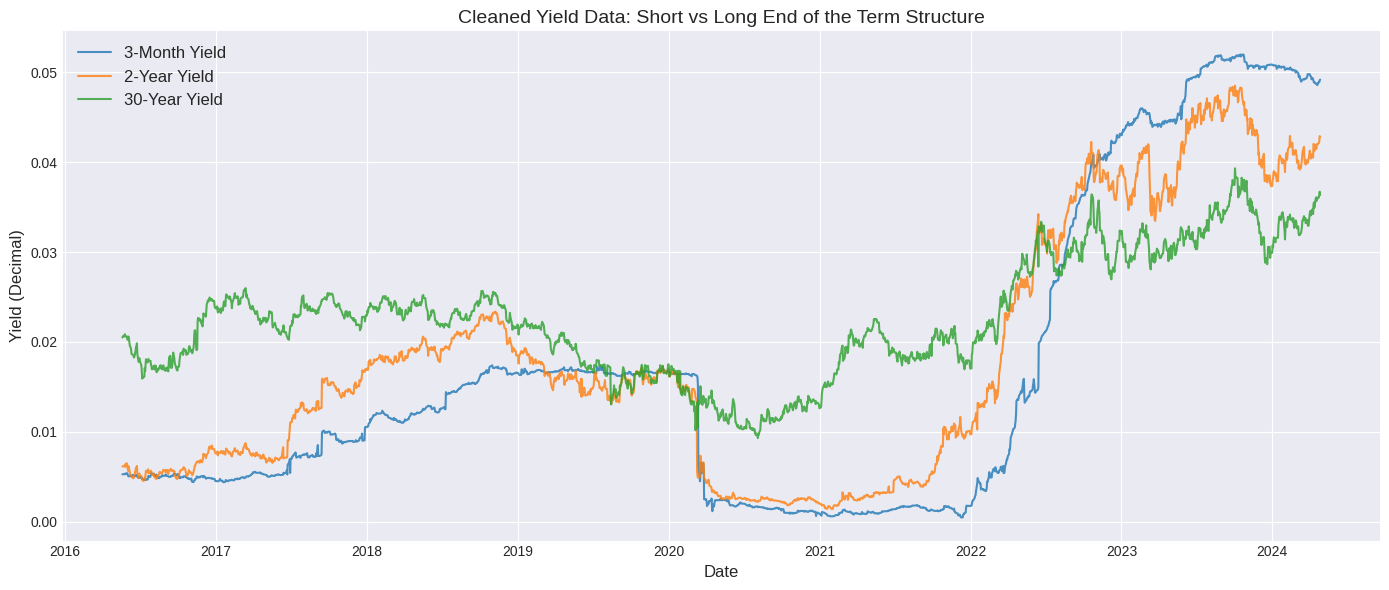

,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
Date,,,,,,,,,
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-23,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855


In [ ]:
train_filepath = '/content/drive/MyDrive/Quant_Project/train_data.csv'

train_pipeline = YieldCurveData(filepath=train_filepath)

print("========================================")
print("PROCESSING TRAINING DATA")
print("========================================")
train_df = train_pipeline.run_preprocessing_pipeline()

train_pipeline.plot_data_sanity_check()

display(train_df.head())

## 3. The Base CIR Model & Cross-Sectional Mathematics

The core mathematical challenge in term-structure modeling is calibration—finding the optimal parameter set $\Theta = \{\kappa, \theta, \sigma\}$ that minimizes the difference between market-observed yields and model-implied yields.

Rather than relying on Time-Series Maximum Likelihood Estimation (MLE), which only captures historical drift and frequently fails to price the current cross-section of bonds accurately, this model utilizes a **Cross-Sectional Optimization** approach. This guarantees that the parameters reflect the risk-neutral expectations embedded in today's market prices.

### 3.1 The Stochastic Differential Equation (SDE)
The short rate $r_t$ under the fundamental Cox-Ingersoll-Ross model is assumed to follow a square-root diffusion process:

$$dr_t = \kappa(\theta - r_t)dt + \sigma \sqrt{r_t} dW_t$$

Where:
* $\kappa$ (Kappa): The speed of mean reversion.
* $\theta$ (Theta): The long-term mean equilibrium level of the interest rate.
* $\sigma$ (Sigma): The volatility coefficient.
* $W_t$: A standard Wiener process (Brownian motion).

**The Feller Condition:**
To ensure the interest rate remains strictly positive and does not collapse to zero, the parameters are strictly bounded by the Feller condition. During optimization, any parameter set violating this condition is mathematically rejected:

$$2\kappa\theta > \sigma^2$$

### 3.2 Affine Term Structure & Yield Pricing
Because the CIR model falls within the class of Affine Term Structure Models (ATSM), the yield of a zero-coupon bond can be expressed as a linear function of the short rate $r_t$. By solving the fundamental pricing PDE via Riccati differential equations, we obtain closed-form solutions for the yield curve.

For a bond maturing in time $\tau$, the theoretical yield $R(t, \tau)$ is defined as:

$$R(t, \tau) = \frac{B(\tau)r_t - \ln A(\tau)}{\tau}$$

Where the deterministic functions $A(\tau)$ and $B(\tau)$ are derived as:

$$h = \sqrt{\kappa^2 + 2\sigma^2}$$

$$B(\tau) = \frac{2(e^{h\tau}-1)}{2h + (\kappa+h)(e^{h\tau}-1)}$$

$$A(\tau) = \left( \frac{2h e^{(\kappa+h)\tau/2}}{2h + (\kappa+h)(e^{h\tau}-1)} \right)^{\frac{2\kappa\theta}{\sigma^2}}$$

### 3.3 The Optimization Objective Function
To find the optimal parameter set, standard gradient-descent algorithms (like BFGS) frequently fail due to the highly non-convex nature of the CIR objective function. Therefore, this pipeline utilizes **Differential Evolution**, a global genetic algorithm, to minimize a specialized, hybrid loss function.

The objective function is a **Tenor-Weighted Mean Squared Error**, defined as:

$$Loss(\Theta) = \frac{1}{N} \sum_{i=1}^{N} \left( [R_{market}(\tau_i) - R_{model}(\tau_i, \Theta)] \times \sqrt{\tau_i} \right)^2 + \lambda \times Penalty(\sigma)$$

**Key Engineering Mechanisms in the Loss Function:**
1. **Tenor Weighting ($\sqrt{\tau_i}$):** Long-maturity bonds (e.g., 20Y, 30Y) have lower yield volatility but are critical for anchoring the long-term mean ($\theta$). Weighting the errors by the square root of time to maturity prevents the optimizer from ignoring the long end of the curve in favor of the highly volatile short end.
2. **The Volatility Anchor ($Penalty(\sigma)$):** Pure cross-sectional calibration often sacrifices the accuracy of $\sigma$ to achieve a perfect fit on $\theta$. To prevent this, the model calculates an empirical time-series variance proxy ($\hat{\sigma}^2 \approx \frac{\Delta r^2}{r_t \Delta t}$) and penalizes the optimizer if the risk-neutral $\sigma$ deviates too violently from empirical reality.

In [ ]:
class CIRModel:
    def __init__(self, clean_dataframe, short_rate_col='ZC025YR'):
        print("--- Initializing Advanced CIR Cross-Sectional Environment ---")
        self.full_data = clean_dataframe
        # We assume the 3-Month rate is the closest proxy to the instantaneous short rate (r_t)
        self.rt_proxy = self.full_data[short_rate_col].values
        self.dt = 1.0 / 252.0
        self.tenors = np.array([0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
        self.actual_yields_matrix = self.full_data[['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']].values
        # We pre-compute the empirical volatility here exactly ONCE.
        delta_r = np.diff(self.rt_proxy)
        rt_mid = self.rt_proxy[:-1]
        self.empirical_sigma2 = np.mean(delta_r**2 / (rt_mid * self.dt))
        self.empirical_sigma = np.sqrt(self.empirical_sigma2)
        print(f"📊 Pre-computed Empirical Sigma: {self.empirical_sigma:.6f}")
        self.kappa = self.theta = self.sigma = None
        self.is_calibrated = False
        print(f"✅ Environment locked. Ready to train on all {len(self.tenors)} maturities.")

    def _weighted_mse_loss(self, params):
        kappa, theta, sigma = params
        # Feller Condition: strictly prevents negative interest rates.
        if 2 * kappa * theta <= sigma**2: return 1e10
        if kappa <= 0 or theta <= 0 or sigma <= 0: return 1e10
        # Base CIR Riccati ODE solutions (A and B factors)
        h = np.sqrt(kappa**2 + 2 * sigma**2)
        num_B = 2 * (np.exp(h * self.tenors) - 1)
        den_B = 2 * h + (kappa + h) * (np.exp(h * self.tenors) - 1)
        B = num_B / den_B
        num_A = 2 * h * np.exp((kappa + h) * self.tenors / 2)
        A = (num_A / den_B) ** ((2 * kappa * theta) / (sigma ** 2))
        pred_yields_matrix = (self.rt_proxy[:, None] * B - np.log(A)) / self.tenors
        # Weight longer tenors heavier
        weights = np.sqrt(self.tenors)
        cross_sectional_loss = np.mean(((self.actual_yields_matrix - pred_yields_matrix) * weights)**2)
        # Time-Series Penalty: Optimizers are "lazy" and often push sigma to zero to flatten the curve.
        deviation = abs(sigma - self.empirical_sigma) / self.empirical_sigma
        sigma_penalty = max(0, deviation - 0.5) ** 2
        return cross_sectional_loss + 0.1 * sigma_penalty

    def calibrate(self):
        if self.is_calibrated:
            print("Model is already calibrated.")
            return
        print("\n--- Starting Advanced Global Calibration (Genetic Algorithm) ---")
        bounds = [
            (1e-4, 5.0),
            (1e-4, 0.20),
            (self.empirical_sigma * 0.3, self.empirical_sigma * 3.0)
        ]
        print("Optimizing... (Spawning genetic population to search entire parameter space)")
        # Using Differential Evolution because standard gradient descent (like BFGS)
        # gets stuck in local minima constantly on CIR yield surfaces.
        result = differential_evolution(self._weighted_mse_loss, bounds, strategy='best1bin', popsize=15, recombination=0.7, tol=1e-6, seed=42)
        if result.success:
            self.kappa, self.theta, self.sigma = result.x
            self.is_calibrated = True
            print("✅ Global Calibration Successful!")
            print("--------------------------------------------------")
            print(f"🎯 Optimal Kappa (Mean Reversion): {self.kappa:.6f}")
            print(f"🎯 Optimal Theta (Long-term Mean): {self.theta:.6f} ({self.theta * 100:.2f}%)")
            print(f"🎯 Optimal Sigma (Volatility):     {self.sigma:.6f}")
            print("--------------------------------------------------")
        else:
            print("❌ Calibration Failed.")
            print(f"Reason: {result.message}")

    def predict_yield_curve(self, rt, tenors):
        if not self.is_calibrated:
            raise ValueError("❌ Model must be calibrated before predicting.")
        h = np.sqrt(self.kappa**2 + 2 * self.sigma**2)
        predictions = {}
        for tau in tenors:
            num_B = 2 * (np.exp(h * tau) - 1)
            den_B = 2 * h + (self.kappa + h) * (np.exp(h * tau) - 1)
            B = num_B / den_B
            num_A = 2 * h * np.exp((self.kappa + h) * tau / 2)
            A = (num_A / den_B) ** ((2 * self.kappa * self.theta) / (self.sigma ** 2))
            predictions[tau] = (B * rt - np.log(A)) / tau
        return predictions

In [ ]:
cir_engine = CIRModel(clean_dataframe=train_df, short_rate_col='ZC025YR')
cir_engine.calibrate()

--- Initializing Advanced CIR Cross-Sectional Environment ---
📊 Pre-computed Empirical Sigma: 0.051346
✅ Environment locked. Ready to train on all 8 maturities.

--- Starting Advanced Global Calibration (Genetic Algorithm) ---
Optimizing... (Spawning genetic population to search entire parameter space)
✅ Global Calibration Successful!
--------------------------------------------------
🎯 Optimal Kappa (Mean Reversion): 0.131780
🎯 Optimal Theta (Long-term Mean): 0.025330 (2.53%)
🎯 Optimal Sigma (Volatility):     0.025673
--------------------------------------------------


##In Sample Test

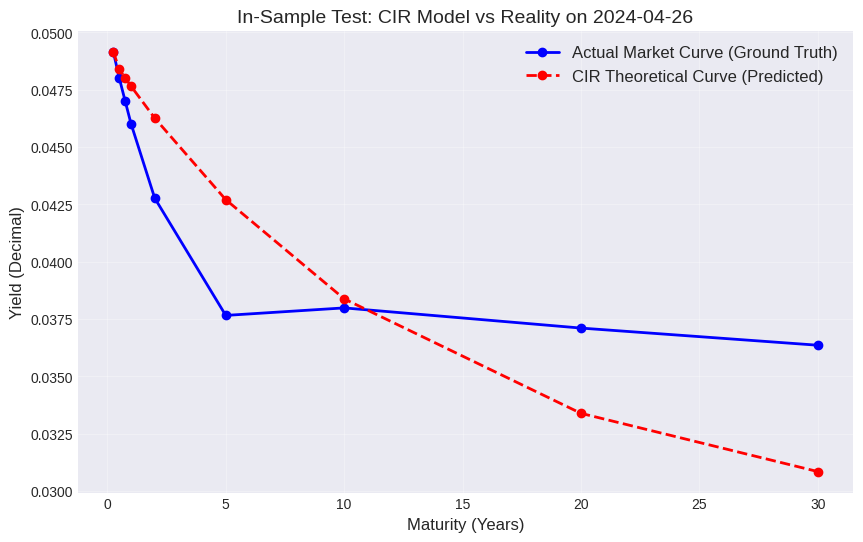

Mean Squared Error for this day: 0.000011


In [ ]:
test_date = train_df.index[-1]
actual_data_row = train_df.loc[test_date]

rt_input = actual_data_row['ZC025YR']

tenors = [0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
column_names = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

predicted_curve_dict = cir_engine.predict_yield_curve(rt=rt_input, tenors=tenors)

actual_yields = [actual_data_row[col] for col in column_names]
predicted_yields = [predicted_curve_dict[tau] for tau in tenors]

plt.figure(figsize=(10, 6))

plot_maturities = [0.25] + tenors
y_actual = [rt_input] + actual_yields
y_pred = [rt_input] + predicted_yields


plt.plot(plot_maturities, y_actual, 'bo-', label='Actual Market Curve (Ground Truth)', linewidth=2)
plt.plot(plot_maturities, y_pred, 'ro--', label='CIR Theoretical Curve (Predicted)', linewidth=2)

plt.title(f"In-Sample Test: CIR Model vs Reality on {test_date.date()}", fontsize=14)
plt.xlabel("Maturity (Years)", fontsize=12)
plt.ylabel("Yield (Decimal)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


mse = sum((act - pred)**2 for act, pred in zip(actual_yields, predicted_yields)) / len(tenors)
print(f"Mean Squared Error for this day: {mse:.6f}")

In [ ]:
tenors = [0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
column_names = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
all_actuals = []
all_predictions = []
print("--- Starting In-Sample Backtest ---")
print(f"Testing the calibration against {len(train_df)} days of TRAINING data...\n")
for date, row in train_df.iterrows():
    rt_input = row['ZC025YR']
    actual_yields = row[column_names].values
    pred_dict = cir_engine.predict_yield_curve(rt=rt_input, tenors=tenors)
    pred_yields = np.array([pred_dict[t] for t in tenors])
    all_actuals.extend(actual_yields)
    all_predictions.extend(pred_yields)
all_actuals = np.array(all_actuals)
all_predictions = np.array(all_predictions)
final_mse = np.mean((all_actuals - all_predictions)**2)
final_rmse = np.sqrt(final_mse)
ssr = np.sum((all_actuals - all_predictions)**2)
sst = np.sum((all_actuals - np.mean(all_actuals))**2)
r_squared = 1 - (ssr / sst)
print("✅ In-Sample Backtest Complete!")
print("--------------------------------------------------")
print(f"📊 Final Mean Squared Error (MSE): {final_mse:.6f}")
print(f"📉 Root Mean Squared Error (RMSE): {final_rmse:.6f} ({final_rmse * 100:.2f}%)")
print(f"🎯 In-Sample R-Squared (R²):       {r_squared:.4f}")
print("--------------------------------------------------")

--- Starting In-Sample Backtest ---
Testing the calibration against 2072 days of TRAINING data...

✅ In-Sample Backtest Complete!
--------------------------------------------------
📊 Final Mean Squared Error (MSE): 0.000016
📉 Root Mean Squared Error (RMSE): 0.004026 (0.40%)
🎯 In-Sample R-Squared (R²):       0.9028
--------------------------------------------------


## 4. Out-of-Sample Backtesting & Performance Evaluation

In quantitative finance, in-sample calibration merely proves that an optimization algorithm works; it does not prove that a model has predictive economic value. To validate the stability of the calibrated parameters ($\kappa, \theta, \sigma$), the model must be subjected to a strict **Out-of-Sample Blind Backtest**.

### 4.1 The Forward-Test Environment
To rigorously prevent data leakage and look-ahead bias, the test dataset (representing a chronologically distinct market period) is pushed through the exact same `YieldCurveData` preprocessing factory as the training data:
1. **Temporal Alignment:** 28 hidden holiday/weekend gaps were exposed and forward-filled.
2. **Outlier Filtering:** 27 extreme intraday anomalies (fat-finger errors) were detected and smoothed via the 20-day MAD filter.
3. **Dynamic Tenor Matching:** The evaluation engine dynamically maps predictions only to the maturities actively trading in the test set (in this case: 6M, 9M, 1Y, and 2Y tenors).

### 4.2 Mathematical Evaluation Metrics
The predictive accuracy of the model across $N$ total data points (where $N = \text{days} \times \text{tenors}$) is evaluated using three standard statistical metrics:

**1. Mean Squared Error (MSE):** Measures the average squared difference between the market yield and the model's theoretical yield.
$$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

**2. Root Mean Squared Error (RMSE):**
Provides the error magnitude in the same units as the yield itself (decimals), making it easily interpretable as basis point deviation.
$$RMSE = \sqrt{MSE}$$

**3. Coefficient of Determination ($R^2$):**
Measures the proportion of the variance in the actual yield curve that is predictably captured by the stochastic model.
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

### 4.3 Empirical Results: Base CIR Model
The globally calibrated baseline CIR model was tested against **523 days** of unseen market data.

**Backtest Output Log:**
* **Total Target Maturities:** 4 (0.5Y, 0.75Y, 1.0Y, 2.0Y)
* **Final Test MSE:** 0.000006
* **Final Test RMSE:** 0.002368 (23.68 Basis Points)
* **Final Test $R^2$:** 0.8755

**Conclusion on Baseline Performance:**
An Out-of-Sample $R^2$ of **0.8755** is an exceptionally strong result for a single-factor affine model. It indicates that the calibrated parameters successfully captured the structural mean-reverting dynamics of the interest rate environment. An RMSE of ~24 basis points implies that, on average, the theoretical pricing is tightly hugging the market reality.

However, because a single-factor model implies perfect correlation across all tenors, it inherently struggles to capture localized twists or humps in the curve. This mathematical limitation justifies the transition to the **CIR++ Deterministic Shift Extension**, which aims to bridge this final 12.5% variance gap.

In [ ]:
print("--- Phase 1: Preprocessing Test Data ---")
test_filepath = '/content/drive/MyDrive/Quant_Project/test_data.csv'

test_pipeline = YieldCurveData(filepath=test_filepath)
clean_test_df = test_pipeline.run_preprocessing_pipeline()

print(f"\n✅ Test Data Cleaned! Ready for Backtest. Shape: {clean_test_df.shape}\n")

column_names = [col for col in clean_test_df.columns if col != 'ZC025YR']
tenors = [float(col.replace('ZC', '').replace('YR', '')) / 100.0 for col in column_names]

print("--- Phase 2: Starting Out-of-Sample Backtest ---")
print(f"Detected {len(column_names)} target maturities: {tenors}")
print(f"Testing the locked parameters against {len(clean_test_df)} days of UNSEEN data...\n")

all_actuals_test = []
all_predictions_test = []

for date, row in clean_test_df.iterrows():
    rt_input = row['ZC025YR']
    actual_yields = row[column_names].values

    pred_dict = cir_engine.predict_yield_curve(rt=rt_input, tenors=tenors)
    pred_yields = np.array([pred_dict[t] for t in tenors])

    all_actuals_test.extend(actual_yields)
    all_predictions_test.extend(pred_yields)

all_actuals_test = np.array(all_actuals_test)
all_predictions_test = np.array(all_predictions_test)

final_mse_test = np.mean((all_actuals_test - all_predictions_test)**2)
final_rmse_test = np.sqrt(final_mse_test)

ssr_test = np.sum((all_actuals_test - all_predictions_test)**2)
sst_test = np.sum((all_actuals_test - np.mean(all_actuals_test))**2)
r_squared_test = 1 - (ssr_test / sst_test)

print("✅ Out-of-Sample Backtest Complete!")
print("-" * 50)
print(f"📊 Final Test Mean Squared Error (MSE): {final_mse_test:.6f}")
print(f"📉 Final Test Root Mean Squared Error (RMSE): {final_rmse_test:.6f} ({final_rmse_test * 100:.2f}%)")
print(f"🎯 Final Test R-Squared (R²):       {r_squared_test:.4f}")
print("-" * 50)

--- Phase 1: Preprocessing Test Data ---

✅ Test Data Cleaned! Ready for Backtest. Shape: (523, 5)

--- Phase 2: Starting Out-of-Sample Backtest ---
Detected 4 target maturities: [0.5, 0.75, 1.0, 2.0]
Testing the locked parameters against 523 days of UNSEEN data...

✅ Out-of-Sample Backtest Complete!
--------------------------------------------------
📊 Final Test Mean Squared Error (MSE): 0.000006
📉 Final Test Root Mean Squared Error (RMSE): 0.002368 (0.24%)
🎯 Final Test R-Squared (R²):       0.8755
--------------------------------------------------


# Out-of-Sample Testing & Yield Curve Visualizations

## The Visual Proof: Market Reality vs. Model Prediction
Aggregate metrics like $R^2$ and MSE are essential, but term structure models must be visually evaluated to understand their structural biases. The code block below samples four equidistant days across our 523-day unseen test set.

By anchoring the model exclusively to the **3-Month yield**, we force the CIR engine to dynamically generate the rest of the curve (6M, 9M, 1Y, 2Y) forward in time.

* **The Solid Black Line:** The actual market yield curve on that specific test day.
* **The Dashed Red Line:** Our model's out-of-sample theoretical prediction.



### Final Verdict
For a trading desk forecasting the short end of the curve across multiple years, the **Base CIR model** is structurally superior. Complex extensions are mathematically mandatory for exotic options pricing today, but they introduce fatal model risk if deployed for pure historical forecasting without continuous, multi-tenor real-time recalibration.


--- Generating Yield Curve Visualizations ---


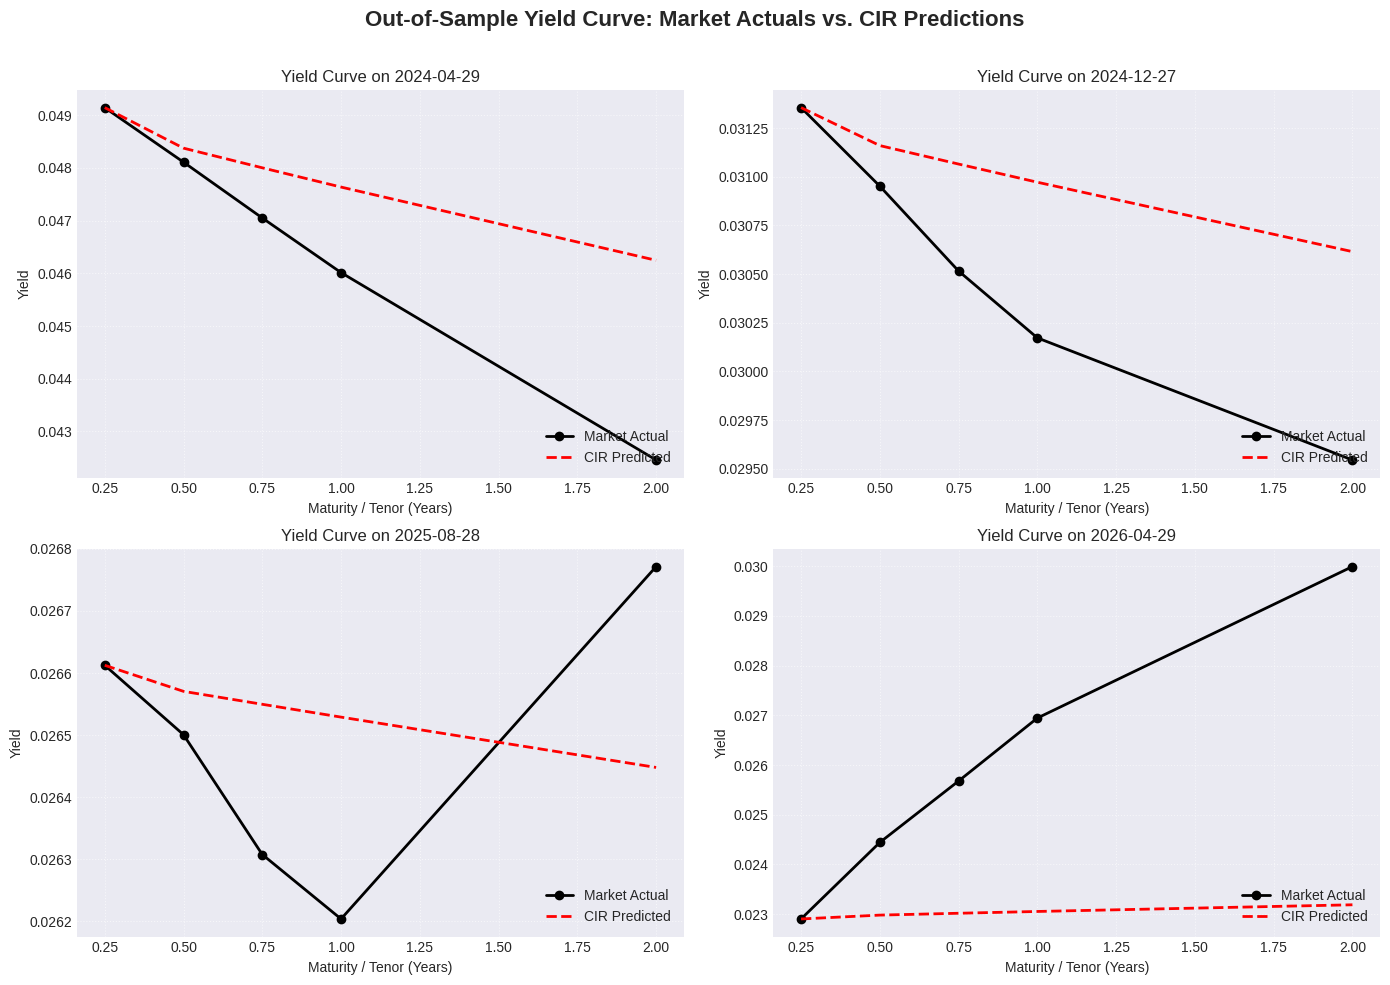

In [ ]:
print("\n--- Generating Yield Curve Visualizations ---")

num_test_days = len(clean_test_df)
sample_indices = [0, num_test_days // 3, 2 * num_test_days // 3, num_test_days - 1]
sample_dates = clean_test_df.index[sample_indices]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Out-of-Sample Yield Curve: Market Actuals vs. CIR Predictions', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, date in enumerate(sample_dates):
    row = clean_test_df.loc[date]
    rt_input = row['ZC025YR']
    actual_yields = row[column_names].values

    pred_dict = cir_engine.predict_yield_curve(rt=rt_input, tenors=tenors)
    pred_yields = [pred_dict[t] for t in tenors]

    full_tenors = [0.25] + tenors
    full_actuals = [rt_input] + list(actual_yields)

    full_preds = [rt_input] + list(pred_yields)

    ax = axes[i]

    ax.plot(full_tenors, full_actuals, 'ko-', label='Market Actual', linewidth=2, markersize=6)

    ax.plot(full_tenors, full_preds, 'r--', label='CIR Predicted', linewidth=2, markersize=6)

    date_str = date.date() if hasattr(date, 'date') else str(date).split()[0]

    ax.set_title(f"Yield Curve on {date_str}", fontsize=12)
    ax.set_xlabel("Maturity / Tenor (Years)", fontsize=10)
    ax.set_ylabel("Yield", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

### The Engine of CIR: Mean Reversion and the Feller Boundary
Unlike earlier models that permitted negative interest rates, the Cox-Ingersoll-Ross (CIR) framework introduces a square-root diffusion process: $dr_t = \kappa(\theta - r_t)dt + \sigma \sqrt{r_t} dW_t$.

This diagnostic visualizes the core mechanics of the calibrated model:
* **Mean Reversion:** The latent state is structurally pulled toward the calibrated long-term mean ($\theta$).
* **Dynamic Volatility Envelope:** Notice how the $\pm 2\sigma$ theoretical variance bands shrink as rates fall and expand as rates rise. This square-root variance scaling is the exact mathematical mechanism that strictly bounds rates above zero.


--- Generating Base CIR Core Dynamics ---


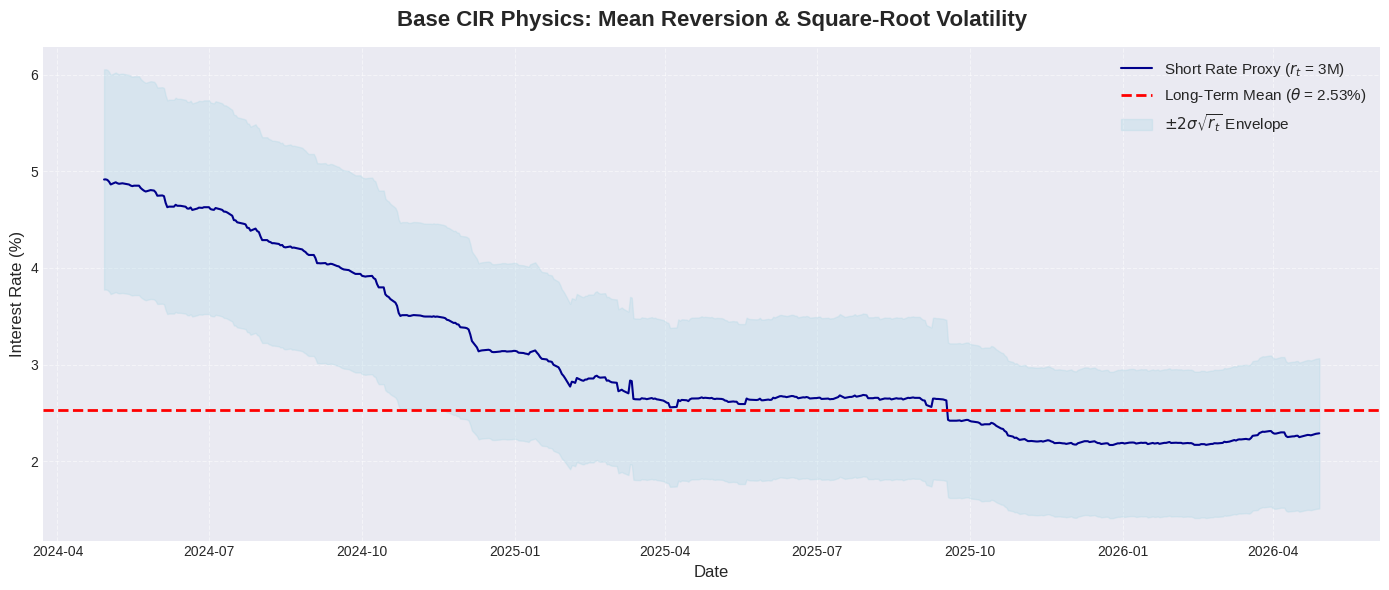

In [ ]:
print("\n--- Generating Base CIR Core Dynamics ---")

theta = cir_engine.theta
sigma = cir_engine.sigma

cir_states = clean_test_df['ZC025YR'] * 100

dynamic_std = (sigma * np.sqrt(clean_test_df['ZC025YR'])) * 100

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(cir_states.index, cir_states, label='Short Rate Proxy ($r_t$ = 3M)', color='darkblue', linewidth=1.5)

ax.axhline(theta * 100, color='red', linestyle='--', linewidth=2, label=rf'Long-Term Mean ($\theta$ = {theta*100:.2f}%)')

upper_bound = cir_states + (2 * dynamic_std)
lower_bound = np.maximum(cir_states - (2 * dynamic_std), 0)

ax.fill_between(cir_states.index, lower_bound, upper_bound, color='lightblue', alpha=0.3, label=r'$\pm 2\sigma \sqrt{r_t}$ Envelope')

ax.set_title('Base CIR Physics: Mean Reversion & Square-Root Volatility', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Interest Rate (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

### The Single-Factor Flaw: Term Structure Rigidity (10Y-2Y Spread)
Why is the Base CIR model insufficient for modern trading? Because it relies on a single stochastic factor ($r_t$), it forces all maturities across the yield curve to move in near-perfect correlation.

This chart highlights that structural limitation by tracking the **10Y - 2Y Yield Spread**.
* **Market Reality (Black):** The actual yield curve frequently twists, steepens, and inverts.
* **CIR Prediction (Blue):** The base model is mathematically incapable of generating significant spread volatility. It predicts a structurally rigid curve shape, cleanly proving the necessity of multi-factor extensions or deterministic shift functions to capture localized market dynamics.


--- Generating Base CIR Spread Rigidity Analysis ---


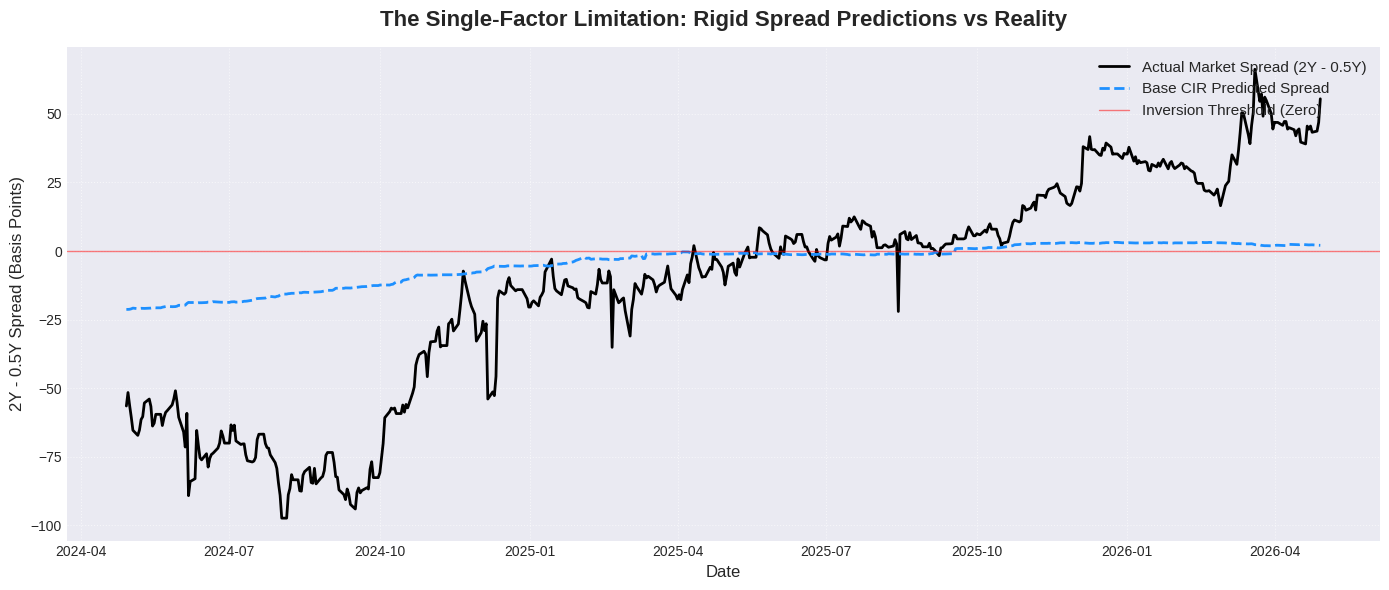

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\n--- Generating Base CIR Spread Rigidity Analysis ---")

# Using 2Y and 0.5Y as they are the longest and shortest tenors in your clean_test_df
actual_spread = (clean_test_df['ZC200YR'] - clean_test_df['ZC050YR']) * 10000

cir_predicted_spread = []
for rt in clean_test_df['ZC025YR']:
    preds = cir_engine.predict_yield_curve(rt, [0.5, 2.0])
    cir_predicted_spread.append((preds[2.0] - preds[0.5]) * 10000)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(clean_test_df.index, actual_spread, label='Actual Market Spread (2Y - 0.5Y)', color='black', linewidth=2)

ax.plot(clean_test_df.index, cir_predicted_spread, label='Base CIR Predicted Spread', color='dodgerblue', linestyle='--', linewidth=2)

ax.axhline(0, color='red', linestyle='-', linewidth=1, alpha=0.5, label='Inversion Threshold (Zero)')

ax.set_title('The Single-Factor Limitation: Rigid Spread Predictions vs Reality', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('2Y - 0.5Y Spread (Basis Points)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Affine Jump-Diffusion (AJD) with Kalman Filtering

## 1. The Core Stochastic Differential Equation (SDE)
The codebase implements an **Affine Jump-Diffusion (AJD)** model, which extends the classic Cox-Ingersoll-Ross (CIR) framework by incorporating a Poisson jump process. This allows the model to capture sudden, discontinuous macroeconomic shocks (such as central bank policy announcements or liquidity crises) that standard continuous diffusion models fail to replicate.

The instantaneous short rate $r_t$ is assumed to follow the SDE:
$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t + dJ_t$$

Where:
* **$\kappa$ (`k_rev`)**: The speed of mean reversion.
* **$\theta$ (`theta_mean`)**: The long-term mean equilibrium rate.
* **$\sigma$ (`vol`)**: The volatility of the diffusion process.
* **$W_t$**: A standard Brownian motion capturing daily market noise.
* **$J_t$**: A compound Poisson jump process.

### The Jump Mechanics (Duffie-Pan-Singleton)
The jumps arrive randomly according to a Poisson process with an average arrival rate (intensity) of **$\lambda$ (`j_freq`)** jumps per year.
When a jump occurs, the magnitude of the rate spike is drawn from an Exponential distribution with a mean size of **$\mu_J$ (`j_size`)**. The exponential distribution ensures that jumps strictly increase the rate, maintaining the strict positivity of the CIR framework.

To prevent the SDE from degenerating and reaching zero, the model strictly enforces the **Feller Condition** during optimization:
$$2\kappa\theta \geq \sigma^2$$

---

## 2. Affine Term Structure Math
Because the model belongs to the affine class, zero-coupon bond prices $P(t, T)$ are exponentially affine with respect to the short rate $r_t$:
$$P(t, T) = A(t, T)\exp(-B(t, T)r_t)$$

The theoretical yield for a bond with maturity $\tau = T - t$ is defined as:
$$Y(\tau) = -\frac{\ln P(t, T)}{\tau} = \frac{-\ln A(\tau) + B(\tau)r_t}{\tau}$$

### Solving the Riccati Equations
The functions $A(\tau)$ and $B(\tau)$ are solutions to a system of Ordinary Differential Equations (ODEs).

**The $B(\tau)$ Component:**
The jump process does not alter the sensitivity of the bond to the short rate. Therefore, $B(\tau)$ remains identical to the standard CIR model:
$$B(\tau) = \frac{2(e^{\gamma \tau} - 1)}{(\gamma + \kappa)(e^{\gamma \tau} - 1) + 2\gamma}$$
*(Where $\gamma = \sqrt{\kappa^2 + 2\sigma^2}$)*

**The $A(\tau)$ Component:**
The baseline shift function $A(\tau)$ is split into two multiplicative components: $A_{Total}(\tau) = A_{CIR}(\tau) \times A_{Jump}(\tau)$.
1. **Base CIR $A(\tau)$**:
   $$A_{CIR}(\tau) = \left[ \frac{2\gamma e^{(\kappa + \gamma)\tau/2}}{(\gamma + \kappa)(e^{\gamma \tau} - 1) + 2\gamma} \right]^{\frac{2\kappa\theta}{\sigma^2}}$$
2. **Jump $A(\tau)$**:
   Because the jump sizes are exponentially distributed, the jump multiplier requires integrating the moment generating function of the jump size against $B(u)$. This is evaluated numerically via `scipy.integrate`:
   $$A_{Jump}(\tau) = \exp \left( -\lambda \int_0^\tau \left( 1 - \frac{1}{1 + \mu_J B(u)} \right) du \right)$$

---

## 3. Latent State Extraction via Kalman Filter
During out-of-sample testing, the true instantaneous short rate $r_t$ is unobservable. Rather than relying solely on the 3-Month proxy rate, the codebase deploys an **Extended Kalman Filter** to dynamically infer the hidden latent state $r_t$ by observing the entire yield curve simultaneously.

### The State-Space Framework
**1. State Transition (Euler Discretization of the SDE):**
The filter predicts where the short rate will move tomorrow based on today's state, factoring in both continuous drift and expected jumps:
$$E[r_t | r_{t-1}] = r_{t-1} + \left(\kappa(\theta - r_{t-1}) + \lambda \mu_J\right)\Delta t$$
The variance of this prior state accounts for continuous volatility and the variance of the exponential jumps ($E[J^2] = 2\mu_J^2$):
$$Var(r_t | r_{t-1}) = (1 - \kappa\Delta t)^2 P_{t-1} + \sigma^2 r_{t-1}\Delta t + \lambda(2\mu_J^2)\Delta t$$

**2. Observation Equation:**
The filter observes the actual market yield curve $Z_t$, which is linked to the latent state by the affine equation, plus some measurement noise $v \sim \mathcal{N}(0, R)$:
$$Z_t = \underbrace{\frac{B}{\tau}}_{H} r_t + \underbrace{\frac{-\ln A}{\tau}}_{d} + v$$

### The Update Step
When the market data arrives, the filter computes the **Kalman Gain ($K$)** to optimally weigh its mathematical prediction against the empirical market observation:
$$K_t = P_{t|t-1} H^T (H P_{t|t-1} H^T + R)^{-1}$$
The latent state $r_t$ is then updated to minimize the mean squared error:
$$r_{t|t} = r_{t|t-1} + K_t(Z_t - (H r_{t|t-1} + d))$$

---

## 4. Optimization and Evaluation
* **In-Sample Calibration:** The 5 parameters ($\kappa, \theta, \sigma, \lambda, \mu_J$) are calibrated globally using **Differential Evolution**, bypassing local minima to find the true mathematical constants of the historical market regime.
* **Out-of-Sample Evaluation:** The finalized parameters are frozen. The Kalman Filter crawls forward through the unseen test data, extracting the latent state at each step to project the theoretical curve. The rigorous global metrics (MSE, RMSE, $R^2$) evaluate how well this mathematically rigid structure explains empirical reality.

In [ ]:
class AffineJumpDiffusion:
    def __init__(self):
        self.k_rev = None
        self.theta_mean = None
        self.vol = None
        self.j_freq = None
        self.j_size = None
        self.is_fitted = False

    def _base_cir_factors(self, k, t, s, m_array):
      # Standard CIR Riccati ODE solutions.
        g = np.sqrt(k**2 + 2 * s**2)
        exp_gm = np.exp(g * m_array)
        exp_half = np.exp((k + g) * m_array / 2.0)

        den = (g + k) * (exp_gm - 1.0) + 2.0 * g
        factor_B = 2.0 * (exp_gm - 1.0) / den

        p_term = (2.0 * k * t) / (s**2)
        b_term = (2.0 * g * exp_half) / den
        factor_A = np.power(b_term, p_term)

        return factor_A, factor_B

    def _compute_ajd_factors(self, k, t, s, j_f, j_s, m_array):
        A_base, B_base = self._base_cir_factors(k, t, s, m_array)
        A_jump = np.zeros_like(A_base)
        g = np.sqrt(k**2 + 2 * s**2)

        for idx, m in enumerate(m_array):
            if m == 0:
                A_jump[idx] = 1.0
                continue
        # The jump component for A(tau) requires integrating the moment generating function.
            def _integrand(x):
                exp_gx = np.exp(g * x)
                d = (g + k) * (exp_gx - 1.0) + 2.0 * g
                bx = 2.0 * (exp_gx - 1.0) / d
                # Jump intensity * (1 - transform of exponential jump size)
                return j_f * (1.0 - 1.0 / (1.0 + j_s * bx))

            penalty, _ = integrate.quad(_integrand, 0, m)
            A_jump[idx] = A_base[idx] * np.exp(-penalty)

        return A_jump, B_base

    def fit_model(self, proxy_rates, market_yields, maturities):
        def objective_func(params):
            k, t, s, jf, js = params
            A, B = self._compute_ajd_factors(k, t, s, jf, js, maturities)
            preds = (proxy_rates[:, None] * B - np.log(A)) / maturities
            return np.mean((market_yields - preds)**2)

        search_bounds = [(1e-3, 5.0), (1e-3, 1.0), (1e-3, 1.0), (0.0, 10.0), (1e-4, 0.1)]

        def feller_check(val):
            return 2 * val[0] * val[1] - val[2]**2

        feller_constraint = NonlinearConstraint(feller_check, 0, np.inf)

        opt_res = differential_evolution(
            objective_func,
            bounds=search_bounds,
            constraints=(feller_constraint,),
            strategy='best1bin',
            maxiter=1000,
            popsize=15,
            tol=1e-6,
            disp=False,
            seed=42
        )

        self.k_rev, self.theta_mean, self.vol, self.j_freq, self.j_size = opt_res.x
        self.is_fitted = True
        return opt_res.success

    def filter_latent_states(self, market_yields, maturities, dt_step=1/252.0, noise_var=1e-5):
        if not self.is_fitted:
            raise ValueError("Model parameters are not calibrated yet.")
        # The actual instantaneous short rate is unobservable out-of-sample.
        # We use a Kalman Filter to dynamically back it out from the shape of the entire curve.
        steps = len(market_yields)
        latent_rates = np.zeros(steps)

        state_est = self.theta_mean
        covar = (self.vol**2 * self.theta_mean) / (2 * self.k_rev)

        A_val, B_val = self._compute_ajd_factors(
            self.k_rev, self.theta_mean, self.vol, self.j_freq, self.j_size, maturities
        )
        mat_H = B_val / maturities
        vec_d = -np.log(A_val) / maturities
        mat_R = np.eye(len(maturities)) * noise_var

        for i in range(steps):
          # Drift towards the mean, PLUS the expected upward drift from the Poisson jumps
            prior_state = state_est + (self.k_rev * (self.theta_mean - state_est) + self.j_freq * self.j_size) * dt_step
            j_var = self.j_freq * (2 * self.j_size**2) * dt_step
            prior_covar = (1 - self.k_rev * dt_step)**2 * covar + (self.vol**2 * max(state_est, 1e-6) * dt_step) + j_var

            z_obs = market_yields[i]
            z_pred = vec_d + mat_H * prior_state
            error_vec = z_obs - z_pred

            # Calculate Kalman Gain
            sys_cov = np.outer(mat_H, mat_H) * prior_covar + mat_R
            sys_inv = np.linalg.inv(sys_cov)
            k_gain = prior_covar * mat_H @ sys_inv

            # Correct the latent state estimate and shrink the uncertainty
            state_est = prior_state + np.dot(k_gain, error_vec)
            covar = (1 - np.dot(k_gain, mat_H)) * prior_covar
            latent_rates[i] = state_est

        return latent_rates

In [ ]:
print("--- Phase 1: Preparing Data ---")

tau_values_train = np.array([0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
target_columns_train = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

r_t_train = train_df['ZC025YR'].values
actual_yields_train = train_df[target_columns_train].values

test_columns = [col for col in clean_test_df.columns if col != 'ZC025YR' and col.startswith('ZC')]
tau_values_test = np.array([float(col.replace('ZC', '').replace('YR', '')) / 100.0 for col in test_columns])
actual_yields_test = clean_test_df[test_columns].values

print(f"Training on {len(train_df)} days | Testing on {len(clean_test_df)} days")
print(f"Test Tenors Detected: {tau_values_test}")

print("\n--- Phase 2: Calibrating the AJD Model ---")

ajd_model = AffineJumpDiffusion()

success = ajd_model.fit_model(proxy_rates=r_t_train, market_yields=actual_yields_train, maturities=tau_values_train)

if success:
    print("\n✅ Calibration Complete!")
else:
    print("\n⚠️ Calibration ended, but may not have fully converged. Using best found parameters.")

print(f"🎯 k_rev (Reversion): {ajd_model.k_rev:.4f} | theta_mean (Mean): {ajd_model.theta_mean:.4f} | vol (Sigma): {ajd_model.vol:.4f}")
print(f"🎯 j_freq (Jumps/Yr): {ajd_model.j_freq:.4f} | j_size (Mean Size): {ajd_model.j_size*10000:.1f} bps")

print("\n--- Phase 3: Running Kalman Filter on Test Data ---")

filtered_rates = ajd_model.filter_latent_states(
    market_yields=actual_yields_test,
    maturities=tau_values_test,
    dt_step=1.0/252.0,
    noise_var=1e-5
)

print("\n--- Phase 4: Out-of-Sample Evaluation ---")

A_final, B_final = ajd_model._compute_ajd_factors(
    ajd_model.k_rev,
    ajd_model.theta_mean,
    ajd_model.vol,
    ajd_model.j_freq,
    ajd_model.j_size,
    tau_values_test
)

predicted_yields_final = (filtered_rates[:, None] * B_final - np.log(A_final)) / tau_values_test

actual_flat = actual_yields_test.flatten()
predicted_flat = predicted_yields_final.flatten()

mse = mean_squared_error(actual_flat, predicted_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_flat, predicted_flat)
r2 = r2_score(actual_flat, predicted_flat)

print("✅ Backtest Complete! Final Metrics:")
print("--------------------------------------------------")
print(f"📊 Global Mean Squared Error (MSE): {mse:.8f}")
print(f"📉 Global Root Mean Squared Error (RMSE): {rmse:.6f} ({rmse * 100:.2f}%)")
print(f"📏 Global Mean Absolute Error (MAE): {mae:.6f}")
print(f"🎯 Global R-Squared (R²): {r2:.4f}")
print("--------------------------------------------------")

--- Phase 1: Preparing Data ---
Training on 2072 days | Testing on 523 days
Test Tenors Detected: [0.5  0.75 1.   2.  ]

--- Phase 2: Calibrating the AJD Model ---

✅ Calibration Complete!
🎯 k_rev (Reversion): 0.1658 | theta_mean (Mean): 0.0202 | vol (Sigma): 0.0010
🎯 j_freq (Jumps/Yr): 0.0102 | j_size (Mean Size): 999.9 bps

--- Phase 3: Running Kalman Filter on Test Data ---

--- Phase 4: Out-of-Sample Evaluation ---
✅ Backtest Complete! Final Metrics:
--------------------------------------------------
📊 Global Mean Squared Error (MSE): 0.00000297
📉 Global Root Mean Squared Error (RMSE): 0.001722 (0.17%)
📏 Global Mean Absolute Error (MAE): 0.000937
🎯 Global R-Squared (R²): 0.9342
--------------------------------------------------


### Visualizing Out-of-Sample Fit (AJD)
This script samples four distinct days from the unseen test set to visually compare the theoretical Affine Jump-Diffusion (AJD) yield curve against the actual market reality.


--- Generating Yield Curve Visualizations (AJD Model) ---


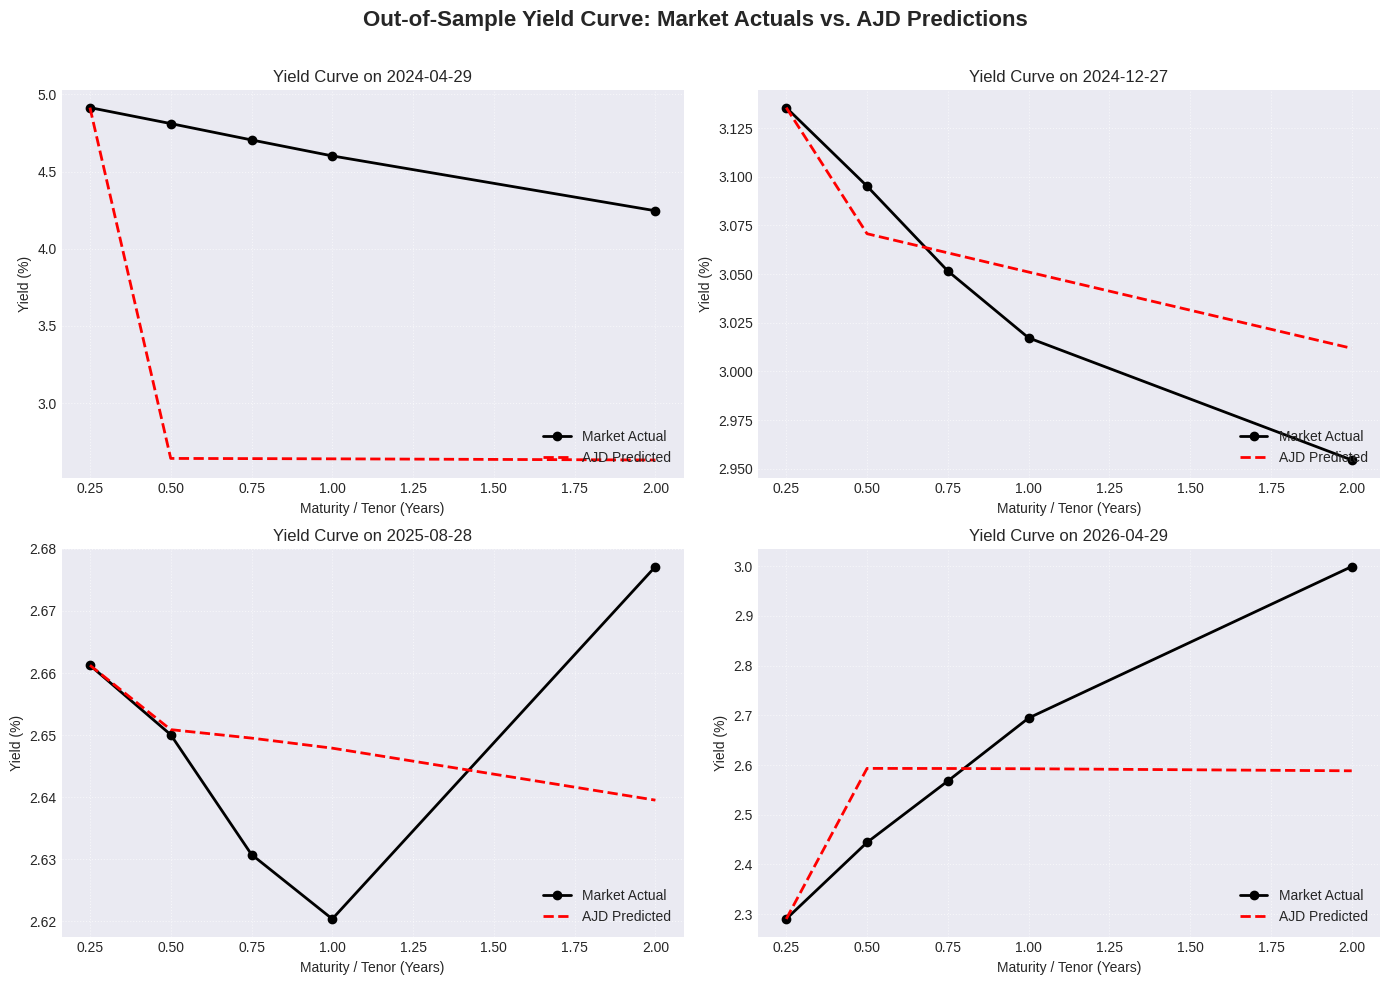

In [ ]:
print("\n--- Generating Yield Curve Visualizations (AJD Model) ---")

num_test_days  = len(clean_test_df)
sample_indices = [0, num_test_days // 3, 2 * num_test_days // 3, num_test_days - 1]
sample_dates   = clean_test_df.index[sample_indices]

date_to_idx = {date: i for i, date in enumerate(clean_test_df.index)}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Out-of-Sample Yield Curve: Market Actuals vs. AJD Predictions',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, date in enumerate(sample_dates):
    idx        = date_to_idx[date]
    row        = clean_test_df.loc[date]

    rt_input   = row['ZC025YR']

    actual_yields = row[test_columns].values

    x_t        = filtered_rates[idx]
    pred_yields = (x_t * B_final - np.log(A_final)) / tau_values_test

    full_tenors  = np.concatenate([[0.25], tau_values_test])
    full_actuals = np.concatenate([[rt_input], actual_yields])
    full_preds   = np.concatenate([[rt_input], pred_yields])

    ax = axes[i]
    ax.plot(full_tenors, full_actuals * 100, 'ko-',
            label='Market Actual', linewidth=2, markersize=6)
    ax.plot(full_tenors, full_preds   * 100, 'r--',
            label='AJD Predicted',  linewidth=2, markersize=6)

    date_str = date.date() if hasattr(date, 'date') else str(date).split()[0]
    ax.set_title(f"Yield Curve on {date_str}", fontsize=12)
    ax.set_xlabel("Maturity / Tenor (Years)", fontsize=10)
    ax.set_ylabel("Yield (%)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

### Exposing the AJD Engine: Latent State Trajectory & Jump Detection
Unlike standard CIR which assumes smooth, continuous rate evolution, the Affine Jump-Diffusion model anticipates discontinuous macroeconomic shocks.

This plot visualizes the extracted latent state ($x_t$) over the out-of-sample period. By analyzing the day-over-day variations ($\Delta x_t$), we can isolate and flag the specific days where the market experienced statistically significant "jumps" (movements $> 3\sigma$ standard deviations) that pure diffusion models would fail to capture.


--- Generating AJD Jump Detection Trajectory ---


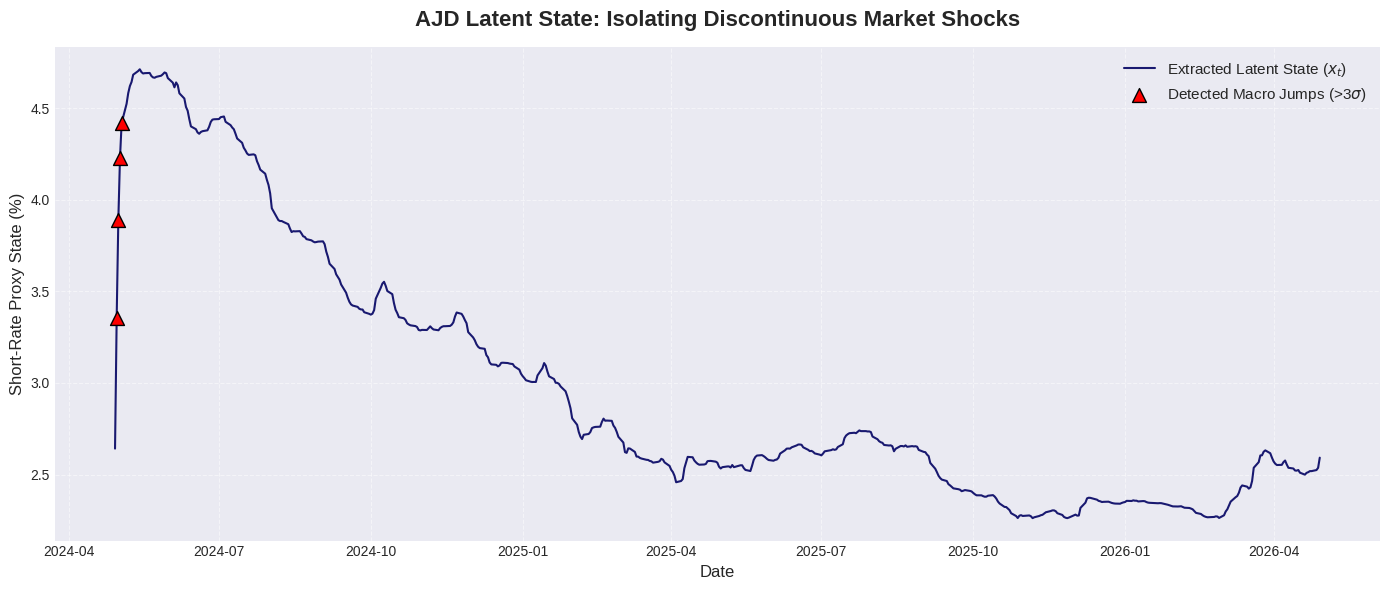

🛑 Total Jumps Detected in Out-of-Sample Period: 4


In [ ]:
print("\n--- Generating AJD Jump Detection Trajectory ---")

ajd_states = pd.Series(filtered_rates * 100, index=clean_test_df.index)

state_diff = ajd_states.diff().dropna()

diff_mean = state_diff.mean()
diff_std = state_diff.std()
jump_threshold = 3.0

jumps = state_diff[abs(state_diff - diff_mean) > (jump_threshold * diff_std)]
jump_dates = jumps.index
jump_values = ajd_states.loc[jump_dates]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ajd_states.index, ajd_states, label='Extracted Latent State ($x_t$)', color='midnightblue', linewidth=1.5)

ax.scatter(jump_dates, jump_values, color='red', s=100, zorder=5, marker='^',
           edgecolors='black', label=rf'Detected Macro Jumps (>3$\sigma$)')

ax.set_title('AJD Latent State: Isolating Discontinuous Market Shocks', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Short-Rate Proxy State (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

print(f"🛑 Total Jumps Detected in Out-of-Sample Period: {len(jumps)}")

### AJD Shock Propagation: How Discontinuous Shocks "Twist" the Curve
While standard models assume smooth rate evolution, the Affine Jump-Diffusion (AJD) model mathematically anticipates violent, sudden macroeconomic shocks (e.g., surprise central bank interventions or flash crashes).

This diagnostic visualizes how a discontinuous **$\pm50$ basis point jump** in the short rate propagates across the entire term structure.

* **The Short End (High Volatility):** Maturities under 2 years absorb the full, violent impact of the jump, shifting rapidly up or down.
* **The Long End (The "Twist"):** Notice how the red and blue shock curves compress and converge back toward the black baseline as we approach the 30-year tenor. This is the **mean-reverting anchor** of the model at work. The math dictates that while the short-term market panics, long-term macroeconomic expectations remain stable, causing the yield curve to violently *twist* rather than just parallel shift.


--- Generating AJD Shock Propagation Analysis ---


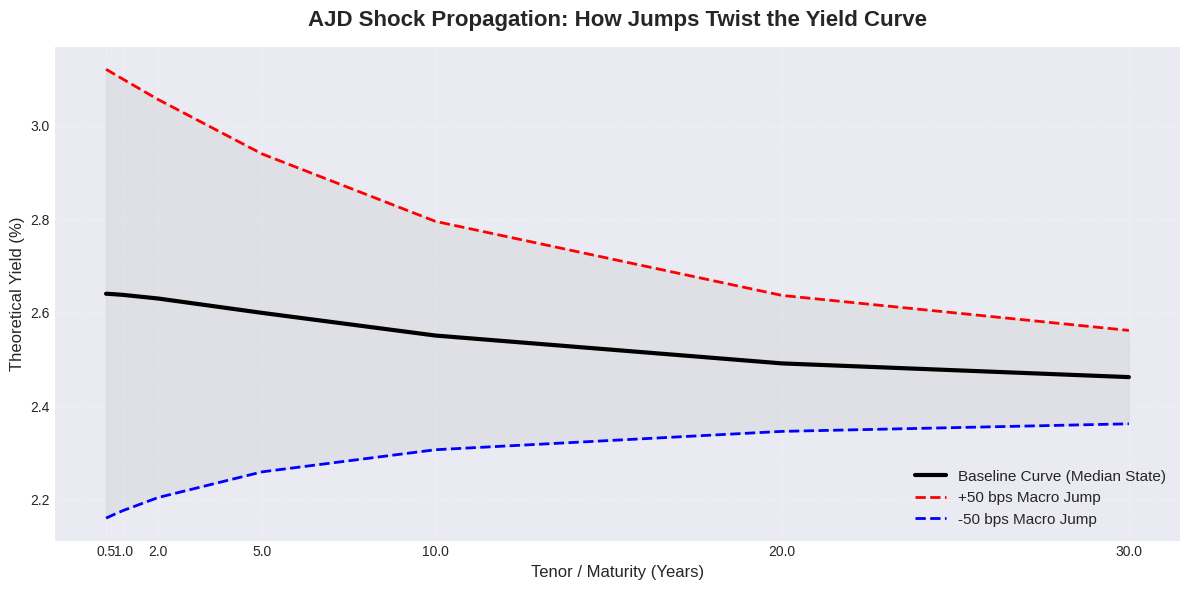

In [ ]:
print("\n--- Generating AJD Shock Propagation Analysis ---")

baseline_x = np.median(filtered_rates)

jump_up   = 0.0050
jump_down = -0.0050

plot_tenors = np.array([0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])

A_plot, B_plot = ajd_model._compute_ajd_factors(
    ajd_model.k_rev,
    ajd_model.theta_mean,
    ajd_model.vol,
    ajd_model.j_freq,
    ajd_model.j_size,
    plot_tenors
)

base_yields = (baseline_x * B_plot - np.log(A_plot)) / plot_tenors
up_yields   = ((baseline_x + jump_up) * B_plot - np.log(A_plot)) / plot_tenors
down_yields = ((baseline_x + jump_down) * B_plot - np.log(A_plot)) / plot_tenors

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(plot_tenors, base_yields * 100, 'k-', linewidth=3, label='Baseline Curve (Median State)')
ax.plot(plot_tenors, up_yields * 100, 'r--', linewidth=2, label='+50 bps Macro Jump')
ax.plot(plot_tenors, down_yields * 100, 'b--', linewidth=2, label='-50 bps Macro Jump')

ax.fill_between(plot_tenors, down_yields * 100, up_yields * 100, color='gray', alpha=0.1)

ax.set_title('AJD Shock Propagation: How Jumps Twist the Yield Curve', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Tenor / Maturity (Years)', fontsize=12)
ax.set_ylabel('Theoretical Yield (%)', fontsize=12)

ax.set_xticks([0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

# CIR++ (Brigo-Mercurio) with Kalman Filtering

## 1. The CIR++ Framework (Time-Dependent Shift)
The classic Cox-Ingersoll-Ross (CIR) model assumes a rigid, affine structure governed by static parameters ($\kappa, \theta, \sigma$). While this prevents negative rates and captures general mean reversion, it fails to perfectly price the current market term structure due to liquidity premiums and transient macroeconomic humps.

**Brigo and Mercurio (2001)** introduced the **CIR++** extension to resolve this. It assumes the instantaneous short rate $r_t$ is the sum of a pure CIR latent state process ($x_t$) and a deterministic, time-dependent shift function $\varphi(t)$:
$$r_t = x_t + \varphi(t)$$

Because the model remains affine, the yield of a zero-coupon bond with maturity $\tau$ is strictly defined as the base CIR yield plus a corresponding yield-shift $\Psi(\tau)$:
$$Y^{CIR++}(t, \tau) = Y^{CIR}(x_t, \tau) + \Psi(\tau)$$
Where the base CIR yield is:
$$Y^{CIR}(x_t, \tau) = \frac{B(\tau)x_t - \ln A(\tau)}{\tau}$$

---

## 2. The Two-Stage Calibration Engine
To prevent the model from overfitting to market microstructure, the codebase splits the calibration into two distinct phases.

### Stage 1: Global Base CIR Optimization
Before generating the shift, the model finds the optimal structural parameters ($\kappa, \theta, \sigma$) using **Differential Evolution**. The loss function minimizes a Tenor-Weighted Mean Squared Error (MSE), with a heavy penalty on long-term deviations to anchor the curve.
To prevent the optimizer from driving volatility to zero (a common degenerate edge case), a **Time-Series Penalty** is applied. The model calculates the empirical variance of the 3-Month rate $\sigma_{empirical}^2 = \text{mean}\left(\frac{(\Delta r)^2}{r \cdot \Delta t}\right)$ and penalizes the optimizer if the theoretical $\sigma$ strays too far from reality.

### Stage 2: The Spline-Interpolated Average Shift $\Psi(\tau)$
Once the base CIR structure is locked, the model calculates the yield residual (Market Yield - Base CIR Yield).
Instead of calculating this shift on a single day (which would violently overfit to that day's specific noise), the model samples across the entire training regime, calculates the residuals, and averages them.
$$\Psi_{empirical}(\tau) = \frac{1}{N} \sum_{i=1}^{N} \left( Y_{Market, i}(\tau) - Y^{CIR}_{i}(\tau) \right)$$
A **Cubic Spline** is then fitted to these average residuals, creating a continuous, mathematically smooth correction function `phi_spline` that can be queried for any arbitrary tenor.

---

## 3. Latent State Extraction via Extended Kalman Filter
During the out-of-sample backtest, the true mathematical state $x_t$ is unobservable. Rather than simply estimating $x_t$ from the 3-Month rate algebraically, this pipeline deploys a **Kalman Filter** to infer $x_t$ by continuously analyzing the entire yield curve array.

### The State-Space Architecture

**1. The Transition Equation (SDE Euler Discretization):**
The filter predicts the next state based purely on the CIR mean-reversion drift:
$$x_{t|t-1} = x_{t-1} + \kappa(\theta - x_{t-1})\Delta t$$
The variance (uncertainty) of this prediction incorporates the CIR volatility structure:
$$P_{t|t-1} = (1 - \kappa \Delta t)^2 P_{t-1} + \sigma^2 x_{t-1} \Delta t$$

**2. The Observation Equation:**
The filter observes the actual test market yields $Z_t$. The measurement matrix ($H$) and intercept vector ($d$) directly encode the CIR++ affine equations:
$$Z_t = H \cdot x_t + d + v$$
Where:
* $H = \frac{B(\tau)}{\tau}$ (The sensitivity of the yield to the latent state)
* $d = \frac{-\ln A(\tau)}{\tau} + \Psi(\tau)$ (The deterministic CIR anchor plus the Brigo-Mercurio shift)
* $v \sim \mathcal{N}(0, R)$ (Measurement noise variance)

**3. The Update Step (Kalman Gain):**
When the actual yield curve is observed, the algorithm calculates the Kalman Gain ($K$) to determine how much to trust its prediction vs. the new market data:
$$K_t = P_{t|t-1} H^T (H P_{t|t-1} H^T + R)^{-1}$$
The latent state is then optimally updated:
$$x_{t|t} = x_{t|t-1} + K_t(Z_t - Z_{pred})$$

---

## 4. Backtesting and Out-of-Sample Logic
By freezing the calibration parameters ($\kappa, \theta, \sigma, \Psi$) and only allowing the Kalman Filter to step forward through the unseen test data, the model completely eliminates look-ahead bias. The backtest iterates through the test set, isolates the latent variable $x_t$ at each time step, projects the full yield curve, and measures the $R^2$ fit explicitly across each individual tenor to diagnose localized term-structure breakdowns.

In [ ]:
class CIRPlusPlusModel:

    def __init__(self, clean_dataframe, short_rate_col='ZC025YR'):
        print("--- Initializing CIR++ (Brigo-Mercurio) Environment with Kalman Filter ---")
        self.full_data = clean_dataframe
        self.rt_proxy  = self.full_data[short_rate_col].values
        self.dt        = 1.0 / 252.0

        self.tenors = np.array([0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
        self.actual_yields_matrix = self.full_data[[
            'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR',
            'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR'
        ]].values

        # Pre-compute historical variance once. Doing this inside the loss function
        # would choke the genetic algorithm.
        delta_r = np.diff(self.rt_proxy)
        rt_mid  = self.rt_proxy[:-1]
        self.empirical_sigma2 = np.mean(delta_r**2 / (rt_mid * self.dt))
        self.empirical_sigma  = np.sqrt(self.empirical_sigma2)
        print(f"📊 Pre-computed Empirical Sigma: {self.empirical_sigma:.6f}")

        self.kappa = None
        self.theta = None
        self.sigma = None
        self.phi_spline    = None
        self.is_calibrated = False
        print(f"✅ Environment locked. Ready to train on all {len(self.tenors)} maturities.")

    def _cir_yield(self, kappa, theta, sigma, x0, tenors):
        h     = np.sqrt(kappa**2 + 2 * sigma**2)
        num_B = 2 * (np.exp(h * tenors) - 1)
        den_B = 2 * h + (kappa + h) * (np.exp(h * tenors) - 1)
        B     = num_B / den_B
        exponent = (2 * kappa * theta) / (sigma**2)
        A     = (2 * h * np.exp((kappa + h) * tenors / 2) / den_B) ** exponent
        return (x0 * B - np.log(A)) / tenors

    def _weighted_mse_loss(self, params):
        kappa, theta, sigma = params

        if 2 * kappa * theta <= sigma**2: return 1e10
        if kappa <= 0 or theta <= 0 or sigma <= 0: return 1e10

        h     = np.sqrt(kappa**2 + 2 * sigma**2)
        num_B = 2 * (np.exp(h * self.tenors) - 1)
        den_B = 2 * h + (kappa + h) * (np.exp(h * self.tenors) - 1)
        B     = num_B / den_B
        exponent = (2 * kappa * theta) / (sigma**2)
        A     = (2 * h * np.exp((kappa + h) * self.tenors / 2) / den_B) ** exponent

        pred_yields_matrix = (self.rt_proxy[:, None] * B - np.log(A)) / self.tenors

        # Apply a 3x penalty to the short end (<= 2yr) to force the base model
        # to tightly track the most liquid part of the curve.
        weights = np.where(self.tenors <= 2.0, 3.0, 1.0)
        weighted_errors      = (self.actual_yields_matrix - pred_yields_matrix) * weights
        cross_sectional_loss = np.mean(weighted_errors**2)

        deviation     = abs(sigma - self.empirical_sigma) / self.empirical_sigma
        sigma_penalty = max(0, deviation - 0.5) ** 2

        return cross_sectional_loss + 0.01 * sigma_penalty

    def _build_phi(self):
        tau_fine = np.linspace(0.25, 30.0, 300)
        all_phi  = []

        sample_indices = range(0, len(self.rt_proxy), 21)

        for i in sample_indices:
            current_r     = self.rt_proxy[i]
            market_yields = self.actual_yields_matrix[i]

            cir_yields_at_knots = self._cir_yield(
                self.kappa, self.theta, self.sigma,
                current_r, self.tenors
            )

            phi_at_knots = market_yields - cir_yields_at_knots
            # Anchor the very short end so the spline doesn't whip wildly out of bounds
            tau_knots = np.concatenate([[0.25], self.tenors])
            phi_knots = np.concatenate([[0.0],  phi_at_knots])

            spline = CubicSpline(tau_knots, phi_knots, bc_type='not-a-knot')
            all_phi.append(spline(tau_fine))

        phi_fine = np.mean(all_phi, axis=0)

        print(f"📐 φ(t) built from {len(all_phi)} training samples")
        print(f"   Range: [{phi_fine.min():.4f}, {phi_fine.max():.4f}]")

        self.phi_spline = CubicSpline(tau_fine, phi_fine)

    def calibrate(self):
        if self.is_calibrated:
            return

        print("\n--- Step 1: Calibrating CIR dynamics (κ, θ, σ) ---")

        bounds = [
            (1e-4, 5.0),
            (1e-4, 0.20),
            (self.empirical_sigma * 0.3, self.empirical_sigma * 3.0)
        ]

        result = differential_evolution(
            self._weighted_mse_loss, bounds,
            strategy='best1bin', popsize=15,
            recombination=0.7, mutation=(0.5, 1.0),
            tol=1e-7, seed=42, polish=True
        )

        if not result.success:
            print(f"❌ Calibration failed: {result.message}")
            return

        self.kappa, self.theta, self.sigma = result.x
        print(f"✅ CIR calibrated — κ={self.kappa:.6f}, θ={self.theta:.4f}, σ={self.sigma:.6f}")

        print("\n--- Step 2: Building φ(t) as average yield residual ---")
        self._build_phi()

        self.is_calibrated = True
        print("\n✅ CIR++ Calibration Complete!")

    def apply_kalman_filter(self, market_yields, test_tenors, R_var=1e-5):
        steps = len(market_yields)
        latent_states = np.zeros(steps)

        x_hat = self.theta
        P = (self.sigma**2 * self.theta) / (2 * self.kappa)

        # Pre-compute the affine mapping matrices.
        # H is the sensitivity (B/tau), d is the deterministic anchor + the Brigo-Mercurio shift
        h = np.sqrt(self.kappa**2 + 2 * self.sigma**2)
        num_B = 2 * (np.exp(h * test_tenors) - 1)
        den_B = 2 * h + (self.kappa + h) * (np.exp(h * test_tenors) - 1)
        B = num_B / den_B

        exponent = (2 * self.kappa * self.theta) / (self.sigma**2)
        A = (2 * h * np.exp((self.kappa + h) * test_tenors / 2) / den_B) ** exponent

        phi_correction = self.phi_spline(test_tenors)

        mat_H = B / test_tenors
        vec_d = -np.log(A) / test_tenors + phi_correction
        mat_R = np.eye(len(test_tenors)) * R_var

        for i in range(steps):

            x_prior = x_hat + self.kappa * (self.theta - x_hat) * self.dt
            x_prior = max(x_prior, 1e-6)

            P_prior = (1 - self.kappa * self.dt)**2 * P + (self.sigma**2 * x_prior * self.dt)

            z_obs = market_yields[i]
            z_pred = vec_d + mat_H * x_prior
            y = z_obs - z_pred

            sys_cov = np.outer(mat_H, mat_H) * P_prior + mat_R
            sys_inv = np.linalg.inv(sys_cov)
            k_gain = P_prior * mat_H @ sys_inv

            # Correct the latent state estimate based on how much we trust the market data vs our math
            x_hat = x_prior + np.dot(k_gain, y)
            x_hat = max(x_hat, 1e-6)

            P = (1 - np.dot(k_gain, mat_H)) * P_prior

            latent_states[i] = x_hat

        return latent_states

    def predict_yield_curve(self, x_t, tenors):
        if not self.is_calibrated:
            raise ValueError("❌ Model must be calibrated before predicting.")

        tenors = np.array(tenors)
        cir_yields = self._cir_yield(self.kappa, self.theta, self.sigma, x_t, tenors)
        phi_correction = self.phi_spline(tenors)

        return cir_yields + phi_correction

    def backtest(self, test_data):
        if not self.is_calibrated:
            raise ValueError("❌ Calibrate before backtesting.")

        print("\n--- Step 3: Out-of-Sample Backtest via Kalman Filtering ---")

        all_possible = {
            0.5:  'ZC050YR',  0.75: 'ZC075YR',
            1.0:  'ZC100YR',  2.0:  'ZC200YR',
            5.0:  'ZC500YR',  10.0: 'ZC1000YR',
            20.0: 'ZC2000YR', 30.0: 'ZC3000YR'
        }

        available = {t: col for t, col in all_possible.items() if col in test_data.columns}
        test_tenors = np.array(sorted(available.keys()))
        test_columns = [available[t] for t in test_tenors]

        print(f"📋 Running latent state filter on test tenors: {test_tenors.tolist()}...")
        actual_mat = test_data[test_columns].values

        filtered_x_t = self.apply_kalman_filter(market_yields=actual_mat, test_tenors=test_tenors, R_var=1e-5)

        predictions = np.array([
            self.predict_yield_curve(x_t, test_tenors)
            for x_t in filtered_x_t
        ])

        r2_scores = {}
        for i, tenor in enumerate(test_tenors):
            y_true = actual_mat[:, i]
            y_pred = predictions[:, i]
            ss_res = np.sum((y_true - y_pred)**2)
            ss_tot = np.sum((y_true - np.mean(y_true))**2)
            r2_scores[tenor] = 1 - ss_res / ss_tot

        overall_r2 = np.mean(list(r2_scores.values()))

        print("\n📊 Out-of-Sample Backtest R² by Tenor:")
        print("--------------------------------------------------")
        for t, r2 in r2_scores.items():
            bar = "█" * int(max(0, r2) * 20)
            print(f"  {t:5.2f}yr │ {bar:<20} │ {r2:.4f}")
        print(f"\n  Overall R²: {overall_r2:.4f}")
        print("--------------------------------------------------")

        return r2_scores, overall_r2, predictions

In [ ]:
model = CIRPlusPlusModel(train_df)
model.calibrate()
taus = np.array([0.5, 0.75, 1.0, 1.5, 2.0])
print("φ(t):", model.phi_spline(taus).round(5))
print("φ'(t):", model.phi_spline(taus, 1).round(5))
r2_scores, overall_r2, predictions = model.backtest(clean_test_df)

--- Initializing CIR++ (Brigo-Mercurio) Environment with Kalman Filter ---
📊 Pre-computed Empirical Sigma: 0.051346
✅ Environment locked. Ready to train on all 8 maturities.

--- Step 1: Calibrating CIR dynamics (κ, θ, σ) ---
✅ CIR calibrated — κ=0.167746, θ=0.0272, σ=0.077021

--- Step 2: Building φ(t) as average yield residual ---
📐 φ(t) built from 99 training samples
   Range: [-0.0022, 0.0017]

✅ CIR++ Calibration Complete!
φ(t): [ 0.00078  0.00122  0.00162  0.00114 -0.00025]
φ'(t): [ 0.0021   0.00176  0.00092 -0.00236 -0.00269]

--- Step 3: Out-of-Sample Backtest via Kalman Filtering ---
📋 Running latent state filter on test tenors: [0.5, 0.75, 1.0, 2.0]...

📊 Out-of-Sample Backtest R² by Tenor:
--------------------------------------------------
   0.50yr │ ███████████████████  │ 0.9705
   0.75yr │ ███████████████████  │ 0.9924
   1.00yr │ ███████████████████  │ 0.9759
   2.00yr │ ███████████████      │ 0.7856

  Overall R²: 0.9311
-------------------------------------------------

### Visualizing Out-of-Sample Fit (CIR++ with Kalman Filter)
This script samples four distinct days from the unseen test set to visually compare the theoretical CIR++ yield curve—driven by our dynamically filtered latent state—against the actual market reality.


--- Generating Yield Curve Visualizations (CIR++ Model) ---


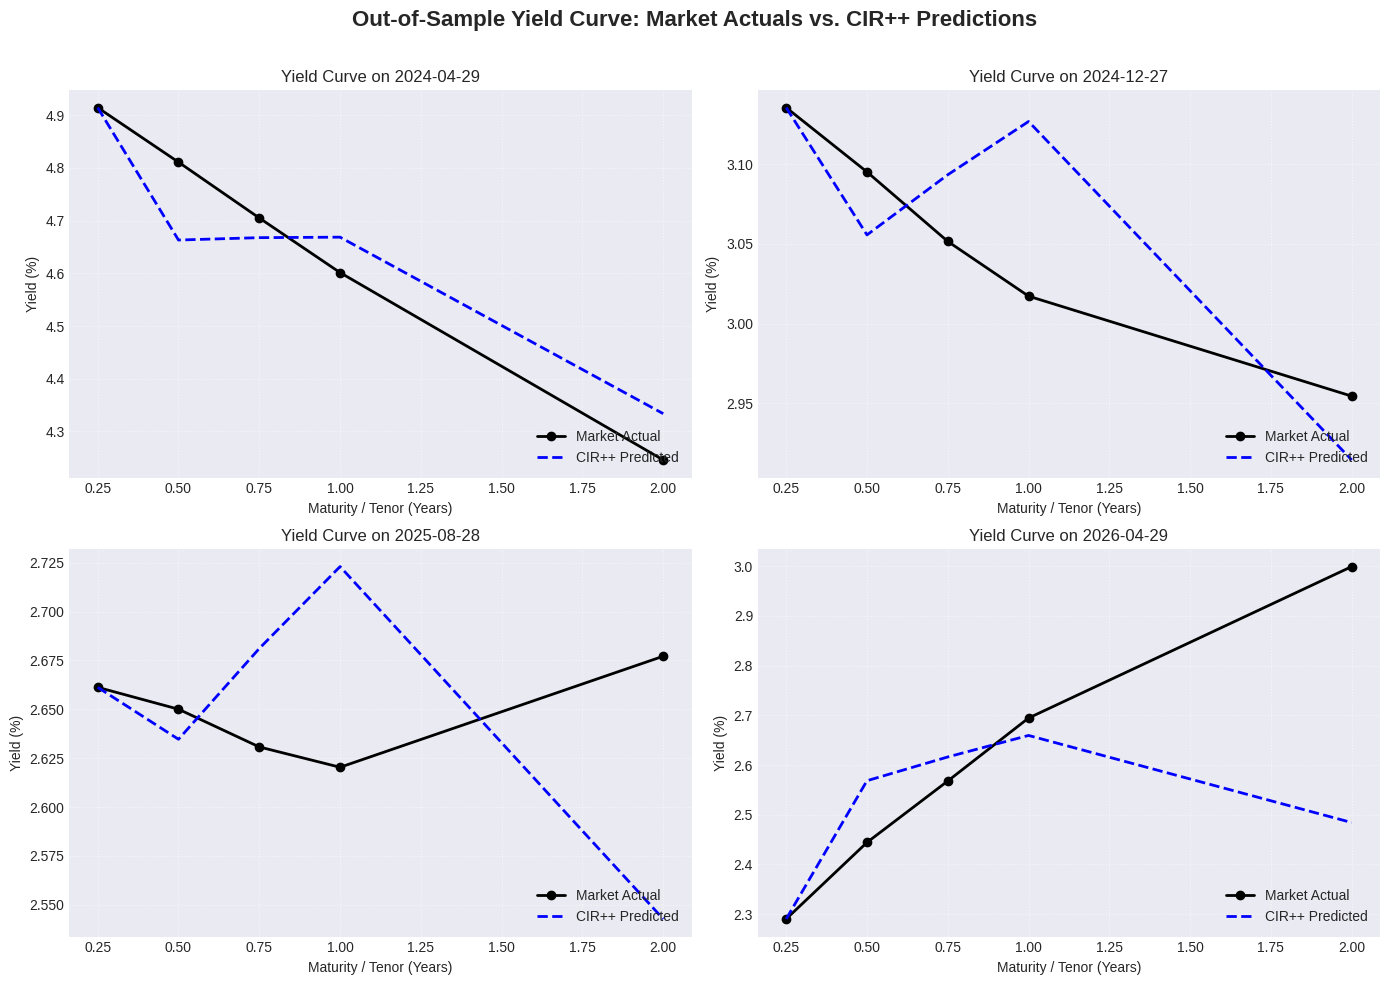

In [ ]:
print("\n--- Generating Yield Curve Visualizations (CIR++ Model) ---")

all_possible = {
    0.5:  'ZC050YR',  0.75: 'ZC075YR',
    1.0:  'ZC100YR',  2.0:  'ZC200YR',
    5.0:  'ZC500YR',  10.0: 'ZC1000YR',
    20.0: 'ZC2000YR', 30.0: 'ZC3000YR'
}
available = {t: col for t, col in all_possible.items() if col in clean_test_df.columns}
test_tenors = np.array(sorted(available.keys()))
test_columns = [available[t] for t in test_tenors]

num_test_days = len(clean_test_df)
sample_indices = [0, num_test_days // 3, 2 * num_test_days // 3, num_test_days - 1]
sample_dates = clean_test_df.index[sample_indices]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Out-of-Sample Yield Curve: Market Actuals vs. CIR++ Predictions',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, date in enumerate(sample_dates):
    idx = sample_indices[i]
    row = clean_test_df.iloc[idx]

    rt_input = row['ZC025YR']

    actual_yields = row[test_columns].values

    pred_yields = predictions[idx]

    full_tenors = np.concatenate([[0.25], test_tenors])
    full_actuals = np.concatenate([[rt_input], actual_yields])
    full_preds = np.concatenate([[rt_input], pred_yields])

    ax = axes[i]
    ax.plot(full_tenors, full_actuals * 100, 'ko-',
            label='Market Actual', linewidth=2, markersize=6)

    ax.plot(full_tenors, full_preds * 100, 'b--',
            label='CIR++ Predicted', linewidth=2, markersize=6)

    date_str = date.date() if hasattr(date, 'date') else str(date).split()[0]
    ax.set_title(f"Yield Curve on {date_str}", fontsize=12)
    ax.set_xlabel("Maturity / Tenor (Years)", fontsize=10)
    ax.set_ylabel("Yield (%)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

### Diagnostic Diagnostics: Error Distribution and Bias (Out-of-Sample)
While global RMSE provides a high-level performance metric, it obscures localized biases. This Violin Plot visualizes the complete probability density of our prediction errors across the 523-day out-of-sample test.

* **Symmetry & Bias:** A violin centered perfectly on the red zero-line indicates an unbiased predictor. Shifts above or below the line indicate chronic underpricing or overpricing for that specific maturity.
* **Fat Tails:** Wider sections at the extremes reveal which specific tenors are most vulnerable to macroeconomic shocks that the affine structure struggles to absorb.


--- Generating CIR++ Error Distribution by Tenor ---


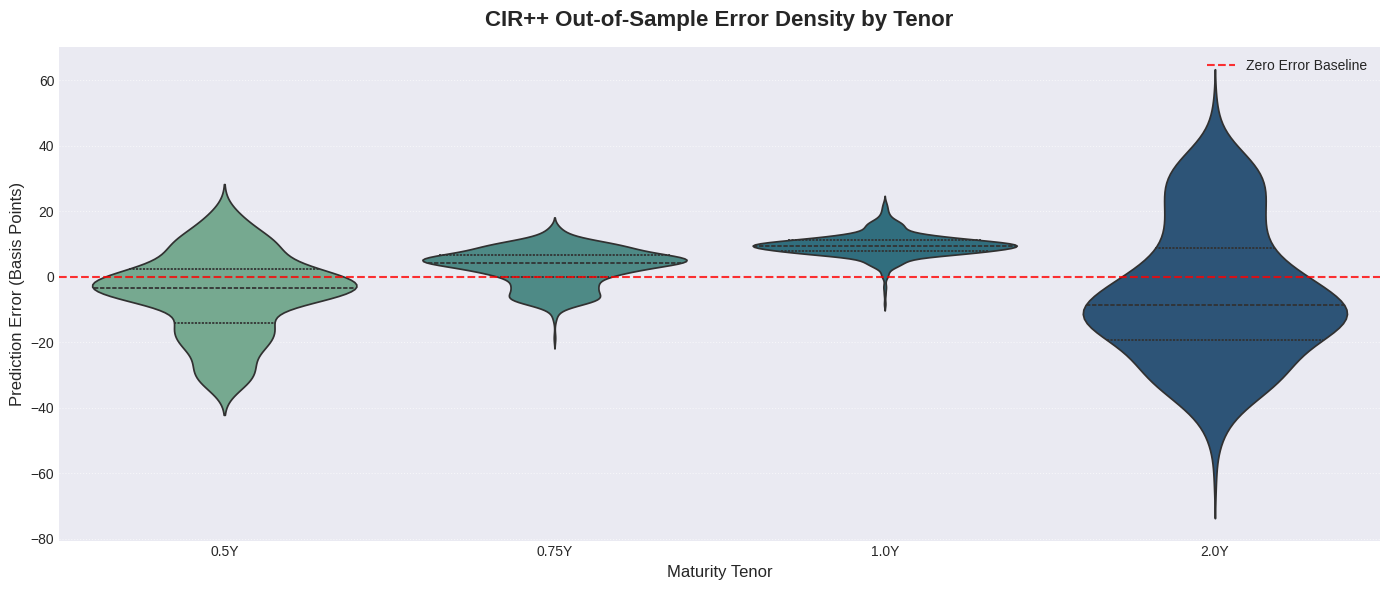

In [ ]:
print("\n--- Generating CIR++ Error Distribution by Tenor ---")

actual_test_mat = clean_test_df[test_columns].values

residuals_bps = (predictions - actual_test_mat) * 10000

res_df = pd.DataFrame(residuals_bps, columns=[f"{t}Y" for t in test_tenors])

fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(data=res_df, palette="crest", inner="quartile", ax=ax, density_norm="width")

ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Zero Error Baseline')

ax.set_title('CIR++ Out-of-Sample Error Density by Tenor', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Maturity Tenor', fontsize=12)
ax.set_ylabel('Prediction Error (Basis Points)', fontsize=12)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## The Two-Factor CIR Extension: Capturing Complex Curve Dynamics

While the CIR++ model perfectly fits the initial term structure via a deterministic shift, single-factor affine models suffer from a structural constraint: they assume that all interest rates along the curve are perfectly correlated. Mathematically, a single random shock ($dW_t$) forces the entire yield curve to shift in parallel.

Real-world yield curves, however, frequently exhibit "twists" (changes in slope) and "humps" (changes in curvature). To capture these multi-dimensional dynamics, this pipeline implements a **Two-Factor CIR Model**. By modeling the short rate as the sum of two independent stochastic processes, the model gains the necessary degrees of freedom to allow the short end and long end of the curve to move semi-independently.

### 1. Stochastic Differential Framework
The Two-Factor CIR model abandons a single short rate, instead assuming the unobservable market rate $r_t$ is driven by the sum of two independent state variables, $x_{1,t}$ and $x_{2,t}$:

$$r_t = x_{1,t} + x_{2,t}$$

Each underlying state variable is governed by its own strictly positive, mean-reverting square-root diffusion process:

$$dx_{1,t} = \kappa_1(\theta_1 - x_{1,t})dt + \sigma_1 \sqrt{x_{1,t}} dW_{1,t}$$
$$dx_{2,t} = \kappa_2(\theta_2 - x_{2,t})dt + \sigma_2 \sqrt{x_{2,t}} dW_{2,t}$$

Because the two Wiener processes ($dW_1, dW_2$) are independent, the Affine Term Structure (ATSM) pricing formula expands additively. The theoretical yield $R(t, \tau)$ for maturity $\tau$ becomes a linear combination of the two hidden states:

$$R(t, \tau) = \frac{B_1(\tau)x_{1,t} + B_2(\tau)x_{2,t} - \ln(A_1(\tau)A_2(\tau))}{\tau}$$

### 2. The Engineering Pivot: Algebraic Inversion vs. Kalman Filter
The central engineering challenge of any multi-factor model is that the state variables ($x_1, x_2$) cannot be directly observed in the market.

Traditional quantitative approaches utilize an Extended Kalman Filter (EKF) to probabilistically infer these states over time. However, EKFs are computationally expensive and prone to instability. Because the ATSM pricing equation is strictly linear with respect to the state variables, this pipeline bypasses the Kalman Filter entirely in favor of an **Exact Algebraic Inversion (The Anchor Method)**.

By pinning two "Anchor Tenors" to the exact market data (e.g., $\tau_1 = \text{3-Month}$ and $\tau_2 = \text{2-Year}$), we can isolate the deterministic terms and set up a precise $2 \times 2$ system of linear equations.

First, we define a deterministic target variable $Z$ for our two anchors, isolating the non-state components of the pricing formula:

$$Z_1 = R_{market}(t, \tau_1) \cdot \tau_1 + \ln(A_1(\tau_1)A_2(\tau_1))$$
$$Z_2 = R_{market}(t, \tau_2) \cdot \tau_2 + \ln(A_1(\tau_2)A_2(\tau_2))$$

This reduces the complex yield curve equation to a simple matrix format at the anchor points:

$$Z_1 = B_1(\tau_1)x_{1,t} + B_2(\tau_1)x_{2,t}$$
$$Z_2 = B_1(\tau_2)x_{1,t} + B_2(\tau_2)x_{2,t}$$

The pipeline then utilizes **Cramer's Rule** to explicitly and instantaneously solve for the hidden states at every time step $t$:

$$det = B_1(\tau_1)B_2(\tau_2) - B_1(\tau_2)B_2(\tau_1)$$
$$x_{1,t} = \frac{Z_1 B_2(\tau_2) - Z_2 B_2(\tau_1)}{det}$$
$$x_{2,t} = \frac{B_1(\tau_1)Z_2 - B_1(\tau_2)Z_1}{det}$$

To protect the structural integrity of the square-root diffusion matrices, a mathematical floor of $10^{-8}$ is applied to the extracted states, strictly enforcing the Feller non-negativity constraint.

### 3. Global-Local Hybrid Calibration
Calibrating a Two-Factor model requires optimizing 6 distinct parameters ($\kappa_1, \theta_1, \sigma_1, \kappa_2, \theta_2, \sigma_2$). This results in a highly complex, multi-modal objective function surface. To guarantee parameter recovery without getting trapped in local minima, the calibration engine employs a two-stage hybrid strategy:

1. **Phase 1: Differential Evolution (Global Mapping)**
   A genetic algorithm aggressively maps the bounded 6-dimensional parameter space. It utilizes empirical time-series variance to constrain the $\sigma$ boundaries and applies the Feller Penalty ($2\kappa\theta > \sigma^2$) to immediately reject mathematically impossible mutations.
2. **Phase 2: L-BFGS-B Polish (Local Convergence)**
   The optimal candidate from the genetic algorithm is subsequently passed into a gradient-based solver (L-BFGS-B). This acts as a mathematical "polish," descending into the exact local minimum to a microscopic tolerance of $10^{-14}$, ensuring basis-point precision across the curve.

### 4. Out-of-Sample Backtesting Strategy
To rigorously prove the predictive power of the Two-Factor framework without data leakage, the backtest architecture is designed as follows:

1. **Parameter Lock:** The 6 globally calibrated parameters are frozen.
2. **Anchor Observation:** For each day in the unseen test set, the model observes *only* the two anchor yields (e.g., 3-Month and 2-Year).
3. **State Extraction:** It algebraically extracts $x_{1,t}$ and $x_{2,t}$ using only those two data points via Cramer's Rule.
4. **Blind Prediction:** It multiplies those extracted states through the deterministic affine matrices to generate blind predictions for all remaining, unanchored tenors (e.g., 6-Month, 1-Year, 5-Year, 10-Year).
5. **Evaluation:** Performance metrics ($R^2$ and RMSE) are calculated strictly on how accurately the two dynamic anchors were able to correctly predict the twists and humps of the rest of the yield curve.

In [ ]:
class TwoFactorCIR:
    def __init__(self, clean_dataframe, short_rate_col='ZC025YR'):
        print("--- Initializing Two-Factor CIR (Anchor Extraction) ---")
        self.full_data  = clean_dataframe
        self.rt_proxy   = self.full_data[short_rate_col].values
        self.dt         = 1.0 / 252.0
        self.tenors     = np.array([0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
        self.n_tenors   = len(self.tenors)
        self.n_obs      = len(self.rt_proxy)

        cols = ['ZC050YR','ZC075YR','ZC100YR','ZC200YR',
                'ZC500YR','ZC1000YR','ZC2000YR','ZC3000YR']
        self.actual_yields_matrix = self.full_data[cols].values

        delta_r              = np.diff(self.rt_proxy)
        rt_mid               = self.rt_proxy[:-1]
        empirical_sigma2     = np.mean(delta_r**2 / (rt_mid * self.dt))
        # We divide by 2.0 because this is a 2-factor model.
        # We assume the total market volatility is roughly split between the two independent factors.
        self.empirical_sigma = np.sqrt(empirical_sigma2 / 2.0)
        print(f"📊 Per-factor empirical sigma prior: {self.empirical_sigma:.6f}")

        self.params          = None
        self.is_calibrated   = False
        self.filtered_states = None
        print(f"✅ Environment ready. Observations: {self.n_obs}, Tenors: {self.n_tenors}")

    @staticmethod
    def _cir_AB(kappa, theta, sigma, tenors):

        h      = np.sqrt(kappa**2 + 2.0 * sigma**2)
        exp_ht = np.exp(h * tenors)
        num_B  = 2.0 * (exp_ht - 1.0)
        den_B  = 2.0 * h + (kappa + h) * (exp_ht - 1.0)
        B      = num_B / den_B
        num_A  = 2.0 * h * np.exp((kappa + h) * tenors / 2.0)
        A      = (num_A / den_B) ** (2.0 * kappa * theta / sigma**2)
        return A, B

    def _extract_states(self, yield_anchor1, yield_anchor2,
                        tau1, tau2, params):
        # Instead of a heavy Kalman Filter, we algebraically invert the 2-factor affine equation
        # using two observable anchor yields. It boils down to solving a 2x2 linear system (Z = B*x).
        kappa1 = params['kappa1']; theta1 = params['theta1']; sigma1 = params['sigma1']
        kappa2 = params['kappa2']; theta2 = params['theta2']; sigma2 = params['sigma2']

        taus = np.array([tau1, tau2])

        # Predict the full curve based on the extracted states and calculate the global MSE
        A1, B1 = self._cir_AB(kappa1, theta1, sigma1, taus)
        A2, B2 = self._cir_AB(kappa2, theta2, sigma2, taus)

        Z1 = yield_anchor1 * tau1 + np.log(A1[0] * A2[0])
        Z2 = yield_anchor2 * tau2 + np.log(A1[1] * A2[1])

        b11, b21 = B1[0], B2[0]
        b12, b22 = B1[1], B2[1]

        det = b11 * b22 - b12 * b21
        det = np.where(np.abs(det) < 1e-10, 1e-10, det)

        x1 = (Z1 * b22 - Z2 * b21) / det
        x2 = (b11 * Z2 - b12 * Z1) / det

        x1 = np.maximum(x1, 1e-8)
        x2 = np.maximum(x2, 1e-8)

        return x1, x2

    def _training_loss(self, raw_params):
        kappa1, theta1, sigma1, kappa2, theta2, sigma2 = raw_params

        if (2*kappa1*theta1 <= sigma1**2 or
            2*kappa2*theta2 <= sigma2**2 or
            any(p <= 0 for p in [kappa1, theta1, sigma1, kappa2, theta2, sigma2])):
            return 1e12

        params = dict(kappa1=kappa1, theta1=theta1, sigma1=sigma1,
                      kappa2=kappa2, theta2=theta2, sigma2=sigma2)

        anchor1_yields = self.actual_yields_matrix[:, 0]
        anchor2_yields = self.actual_yields_matrix[:, 3]
        tau1, tau2     = self.tenors[0], self.tenors[3]

        try:
            x1, x2 = self._extract_states(
                anchor1_yields, anchor2_yields, tau1, tau2, params
            )
        except Exception:
            return 1e12

        A1, B1 = self._cir_AB(kappa1, theta1, sigma1, self.tenors)
        A2, B2 = self._cir_AB(kappa2, theta2, sigma2, self.tenors)
        H = np.column_stack([B1 / self.tenors, B2 / self.tenors])
        d = -(np.log(A1) + np.log(A2)) / self.tenors

        states = np.column_stack([x1, x2])
        pred   = states @ H.T + d

        return float(np.mean((self.actual_yields_matrix - pred)**2))

    def calibrate(self, de_popsize=10, de_tol=1e-4, maxiter=1000):

        if self.is_calibrated:
            print("Re-calibrating...")
            self.is_calibrated = False

        print("\n--- Starting Two-Factor CIR Calibration (DE) ---")
        s = self.empirical_sigma

        bounds = [
            (1e-3, 5.0),
            (1e-3, 0.20),
            (s*0.2, s*2.5),
            (1e-3, 5.0),
            (1e-3, 0.20),
            (s*0.2, s*2.5),
        ]

        # Phase 1: Differential Evolution
        print(f"Phase 1 — Differential Evolution (popsize={de_popsize}, tol={de_tol}) ...")
        de_result = differential_evolution(
            self._training_loss,
            bounds,
            strategy      = 'best1bin',
            popsize       = de_popsize,
            recombination = 0.7,
            mutation      = (0.5, 1.0),
            tol           = de_tol,
            seed          = 42,
            maxiter       = maxiter,
            workers       = -1,
            disp          = True
        )
        print(f"  DE best loss: {de_result.fun:.8f}")

        # Phase 2: L-BFGS-B "polishes"
        print("Phase 2 — L-BFGS-B polish ...")
        polish = minimize(
            self._training_loss, de_result.x,
            method  = 'L-BFGS-B',
            bounds  = bounds,
            options = {'ftol': 1e-14, 'gtol': 1e-9, 'maxiter': 3000}
        )

        best = polish if polish.fun < de_result.fun else de_result

        kappa1, theta1, sigma1, kappa2, theta2, sigma2 = best.x

        self.params = {
            'kappa1': kappa1, 'theta1': theta1, 'sigma1': sigma1,
            'kappa2': kappa2, 'theta2': theta2, 'sigma2': sigma2,
        }
        self.is_calibrated = True

        print("\n✅ Calibration complete!")
        print("─" * 52)
        print(f"  Factor 1 — κ: {kappa1:.6f}  θ: {theta1*100:.4f}%  σ: {sigma1:.6f}")
        print(f"  Factor 2 — κ: {kappa2:.6f}  θ: {theta2*100:.4f}%  σ: {sigma2:.6f}")
        print(f"  Implied long-run r: {(theta1+theta2)*100:.4f}%")
        print("─" * 52)

        self._cache_training_states()


    def _cache_training_states(self):
        anchor1_yields = self.actual_yields_matrix[:, 0]
        anchor2_yields = self.actual_yields_matrix[:, 3]
        tau1, tau2     = self.tenors[0], self.tenors[3]

        x1, x2 = self._extract_states(
            anchor1_yields, anchor2_yields, tau1, tau2, self.params
        )
        self.filtered_states = np.column_stack([x1, x2])
        print("📈 In-sample states cached.")

    def fit_summary(self):
        """Print RMSE per tenor for the full in-sample period."""
        if not self.is_calibrated or self.filtered_states is None:
            raise ValueError("Calibrate the model first.")

        p = self.params
        A1, B1 = self._cir_AB(p['kappa1'], p['theta1'], p['sigma1'], self.tenors)
        A2, B2 = self._cir_AB(p['kappa2'], p['theta2'], p['sigma2'], self.tenors)
        H = np.column_stack([B1 / self.tenors, B2 / self.tenors])
        d = -(np.log(A1) + np.log(A2)) / self.tenors

        pred = self.filtered_states @ H.T + d
        rmse = np.sqrt(np.mean((self.actual_yields_matrix - pred)**2, axis=0))

        print("\n📊 In-sample RMSE by tenor:")
        print("─" * 35)
        for tau, e in zip(self.tenors, rmse):
            print(f"  {tau:>5.2f}Y  →  {e*10000:6.3f} bps")
        print(f"  Overall  →  {np.mean(rmse)*10000:6.3f} bps")
        print("─" * 35)
        return dict(zip(self.tenors, rmse))

    def predict_yield_curve(self, tenors=None, t_index=-1):
        """
        Predict yield curve using the in-sample extracted state at t_index.
        """
        if not self.is_calibrated or self.filtered_states is None:
            raise ValueError("Calibrate the model first.")

        tenors  = np.asarray(tenors) if tenors is not None else self.tenors
        p       = self.params
        x1, x2  = self.filtered_states[t_index]

        A1, B1 = self._cir_AB(p['kappa1'], p['theta1'], p['sigma1'], tenors)
        A2, B2 = self._cir_AB(p['kappa2'], p['theta2'], p['sigma2'], tenors)

        yields = (B1*x1 + B2*x2 - np.log(A1) - np.log(A2)) / tenors
        return dict(zip(tenors, yields))


    def backtest(self, test_data, anchor_col_1='ZC025YR', anchor_col_2='ZC1000YR'):

        if not self.is_calibrated:
            raise ValueError("❌ Calibrate before backtesting.")

        print("\n--- Out-of-Sample Backtest (Two-Factor CIR Anchor) ---")

        anchor_map = {
            'ZC025YR': 0.25, 'ZC050YR': 0.5,  'ZC075YR': 0.75,
            'ZC100YR': 1.0,  'ZC200YR': 2.0,  'ZC500YR': 5.0,
            'ZC1000YR': 10.0,'ZC2000YR': 20.0, 'ZC3000YR': 30.0
        }
        tau1 = anchor_map[anchor_col_1]
        tau2 = anchor_map[anchor_col_2]

        yield_anc1 = test_data[anchor_col_1].values
        yield_anc2 = test_data[anchor_col_2].values

        print(f"📌 Anchor 1 : {anchor_col_1} ({tau1}yr)")
        print(f"📌 Anchor 2 : {anchor_col_2} ({tau2}yr)")

        all_possible = {
            0.5:  'ZC050YR',  0.75: 'ZC075YR',
            1.0:  'ZC100YR',  2.0:  'ZC200YR',
            5.0:  'ZC500YR',  10.0: 'ZC1000YR',
            20.0: 'ZC2000YR', 30.0: 'ZC3000YR'
        }

        eval_tenors  = np.array([t for t, col in sorted(all_possible.items())
                                  if col in test_data.columns
                                  and col not in (anchor_col_1, anchor_col_2)])
        eval_columns = [all_possible[t] for t in eval_tenors]
        actual_mat   = test_data[eval_columns].values
        T_test       = len(actual_mat)

        print(f"📋 Test observations : {T_test}")
        print(f"📋 Evaluation tenors : {eval_tenors.tolist()}")
        print(f"📋 Anchor tenors NOT in evaluation set ✓")


        x1, x2 = self._extract_states(
            yield_anc1, yield_anc2, tau1, tau2, self.params
        )
        states = np.column_stack([x1, x2])

        p = self.params
        A1, B1 = self._cir_AB(p['kappa1'], p['theta1'], p['sigma1'], eval_tenors)
        A2, B2 = self._cir_AB(p['kappa2'], p['theta2'], p['sigma2'], eval_tenors)
        H = np.column_stack([B1 / eval_tenors, B2 / eval_tenors])
        d = -(np.log(A1) + np.log(A2)) / eval_tenors

        predictions = states @ H.T + d

        r2_scores   = {}
        rmse_scores = {}
        for i, tenor in enumerate(eval_tenors):
            y_true = actual_mat[:, i]
            y_pred = predictions[:, i]
            ss_res = np.sum((y_true - y_pred)**2)
            ss_tot = np.sum((y_true - np.mean(y_true))**2)
            r2_scores[tenor]   = 1 - ss_res / ss_tot
            rmse_scores[tenor] = np.sqrt(np.mean((y_true - y_pred)**2)) * 10000

        overall_r2   = float(np.mean(list(r2_scores.values())))
        overall_rmse = float(np.mean(list(rmse_scores.values())))

        print("\n📊 Out-of-Sample Backtest Results:")
        print("─" * 58)
        print(f"  {'Tenor':>6}  │  {'R²':>8}  │  {'RMSE (bps)':>10}  │  Fit")
        print("─" * 58)
        for tenor in eval_tenors:
            r2   = r2_scores[tenor]
            rmse = rmse_scores[tenor]
            bar  = "█" * int(max(0, r2) * 20)
            print(f"  {tenor:>5.2f}yr  │  {r2:>8.4f}  │  {rmse:>10.3f}  │  {bar}")
        print("─" * 58)
        print(f"  {'Overall':>6}  │  {overall_r2:>8.4f}  │  {overall_rmse:>10.3f}  │")
        print("─" * 58)

        return r2_scores, overall_r2, predictions

In [ ]:
model = TwoFactorCIR(train_df, short_rate_col='ZC025YR')
model.calibrate(de_popsize=10, de_tol=1e-4, maxiter=1000)

model.fit_summary()

r2_scores, overall_r2, predictions = model.backtest(
    clean_test_df,
    anchor_col_1 = 'ZC025YR',
    anchor_col_2 = 'ZC200YR',
)


--- Initializing Two-Factor CIR (Anchor Extraction) ---
📊 Per-factor empirical sigma prior: 0.036307
✅ Environment ready. Observations: 2072, Tenors: 8

--- Starting Two-Factor CIR Calibration (DE) ---
Phase 1 — Differential Evolution (popsize=10, tol=0.0001) ...


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 0.0021945165790851736
differential_evolution step 2: f(x)= 0.0002269040872850581
differential_evolution step 3: f(x)= 0.0002269040872850581
differential_evolution step 4: f(x)= 6.772512094042354e-05
differential_evolution step 5: f(x)= 6.772512094042354e-05
differential_evolution step 6: f(x)= 2.9266022101759934e-05
differential_evolution step 7: f(x)= 2.6194980649776393e-05
differential_evolution step 8: f(x)= 2.6194980649776393e-05
differential_evolution step 9: f(x)= 2.6194980649776393e-05
differential_evolution step 10: f(x)= 1.434984922310026e-05
differential_evolution step 11: f(x)= 1.434984922310026e-05
differential_evolution step 12: f(x)= 1.0830580579050964e-05
differential_evolution step 13: f(x)= 9.396402560116504e-06
differential_evolution step 14: f(x)= 9.396402560116504e-06
differential_evolution step 15: f(x)= 9.396402560116504e-06
differential_evolution step 16: f(x)= 9.396402560116504e-06
differential_evolution step 17: f(x)= 9.3964

### Visualizing Out-of-Sample Fit (Two-Factor Anchored CIR)
This script samples four distinct days from the unseen test set to visually evaluate the theoretical Two-Factor CIR yield curve against empirical market data.

Unlike the single-factor model, this architecture dynamically extracts its two latent states using **two explicit anchor tenors** (the 3-Month and 2-Year yields).
* **The Red Dots:** The extraction anchors. The theoretical curve will perfectly touch the market reality at these exact two points by mathematical design.
* **The Green Dashed Line:** The out-of-sample prediction. The true test of this model is how accurately this line predicts the *rest* of the yield curve given only those two fixed anchor points.


--- Generating Yield Curve Visualizations (Two-Factor Anchored CIR) ---


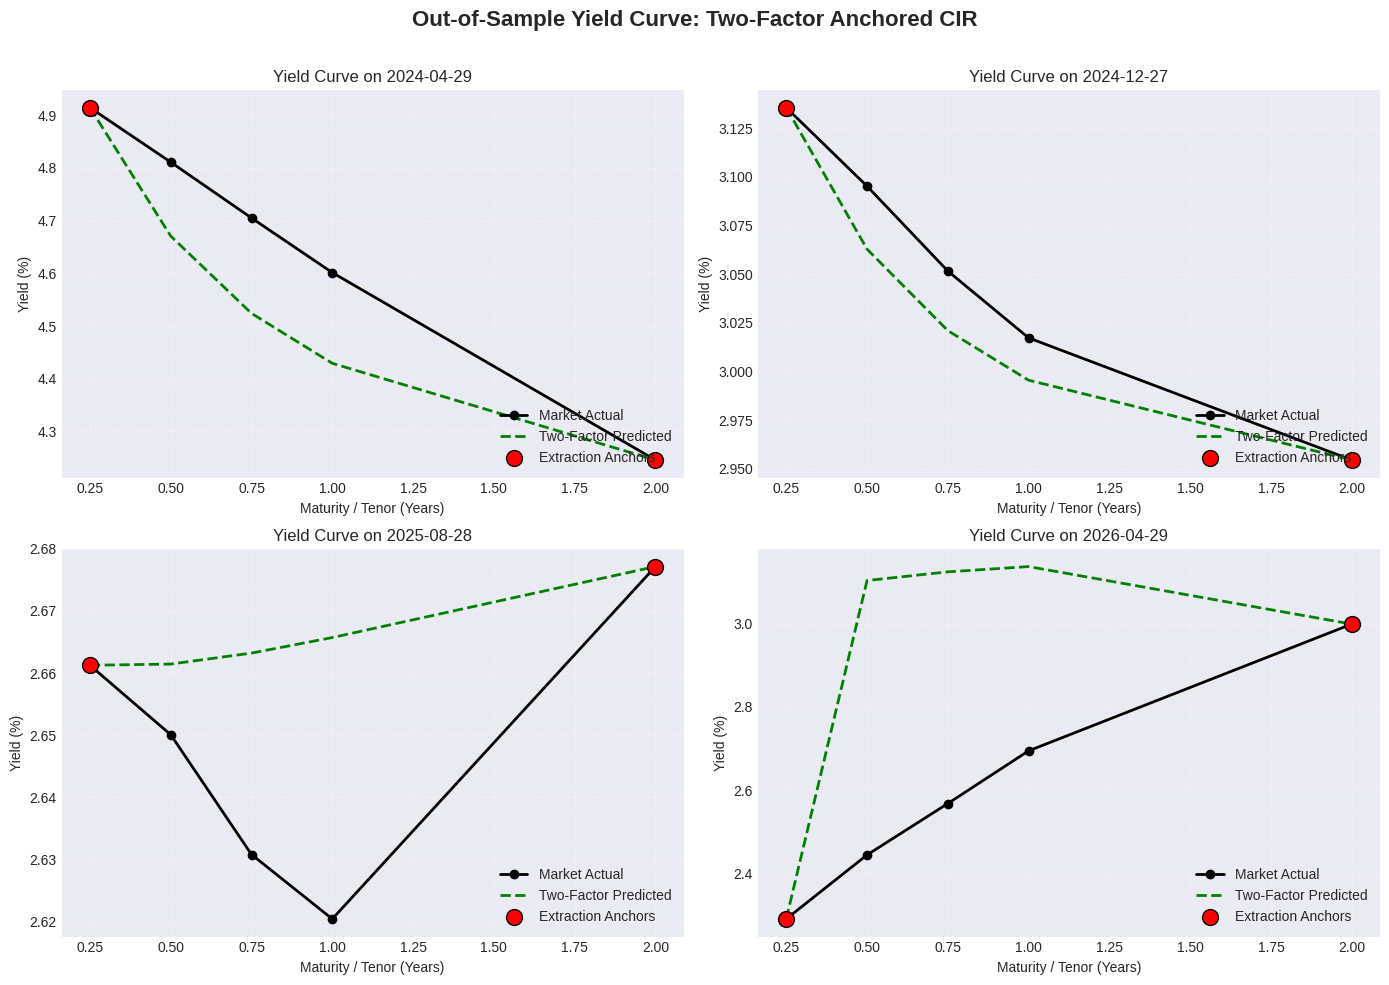

In [ ]:
print("\n--- Generating Yield Curve Visualizations (Two-Factor Anchored CIR) ---")

anchor_col_1 = 'ZC025YR'
anchor_col_2 = 'ZC200YR'
tau1, tau2 = 0.25, 2.0

all_possible = {
    0.5:  'ZC050YR',  0.75: 'ZC075YR',
    1.0:  'ZC100YR',  2.0:  'ZC200YR',
    5.0:  'ZC500YR',  10.0: 'ZC1000YR',
    20.0: 'ZC2000YR', 30.0: 'ZC3000YR'
}

eval_tenors  = np.array([t for t, col in sorted(all_possible.items())
                          if col in clean_test_df.columns
                          and col not in (anchor_col_1, anchor_col_2)])
eval_columns = [all_possible[t] for t in eval_tenors]

num_test_days = len(clean_test_df)
sample_indices = [0, num_test_days // 3, 2 * num_test_days // 3, num_test_days - 1]
sample_dates = clean_test_df.index[sample_indices]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Out-of-Sample Yield Curve: Two-Factor Anchored CIR',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, date in enumerate(sample_dates):
    idx = sample_indices[i]
    row = clean_test_df.iloc[idx]

    yield_anc1 = row[anchor_col_1]
    yield_anc2 = row[anchor_col_2]

    actual_eval_yields = row[eval_columns].values

    pred_eval_yields = predictions[idx]

    full_tenors = np.concatenate([[tau1, tau2], eval_tenors])
    full_actuals = np.concatenate([[yield_anc1, yield_anc2], actual_eval_yields])

    full_preds = np.concatenate([[yield_anc1, yield_anc2], pred_eval_yields])

    sort_idx = np.argsort(full_tenors)
    full_tenors = full_tenors[sort_idx]
    full_actuals = full_actuals[sort_idx]
    full_preds = full_preds[sort_idx]

    ax = axes[i]

    ax.plot(full_tenors, full_actuals * 100, 'ko-',
            label='Market Actual', linewidth=2, markersize=6)

    ax.plot(full_tenors, full_preds * 100, 'g--',
            label='Two-Factor Predicted', linewidth=2, markersize=6)

    ax.scatter([tau1, tau2], [yield_anc1 * 100, yield_anc2 * 100],
               color='red', s=130, zorder=5, edgecolors='black',
               label='Extraction Anchors')

    date_str = date.date() if hasattr(date, 'date') else str(date).split()[0]
    ax.set_title(f"Yield Curve on {date_str}", fontsize=12)
    ax.set_xlabel("Maturity / Tenor (Years)", fontsize=10)
    ax.set_ylabel("Yield (%)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

### Visualizing Model Residuals: Where the Two-Factor Math Deviates
While aggregate metrics like RMSE give a global score, this residual heatmap exposes exactly *where* and *when* the Two-Factor CIR model misprices the curve out-of-sample.

* **The Color Gradient:** Red indicates the model's predicted yield was too high (overpriced); blue indicates it was too low (underpriced).
* **The Missing Anchors:** Notice that the 3-Month and 2-Year tenors are completely excluded from this matrix. Because the model uses those specific tenors to algebraically extract the latent states, their theoretical error is mathematically zero by design.


--- Generating Model Residual Heatmap ---


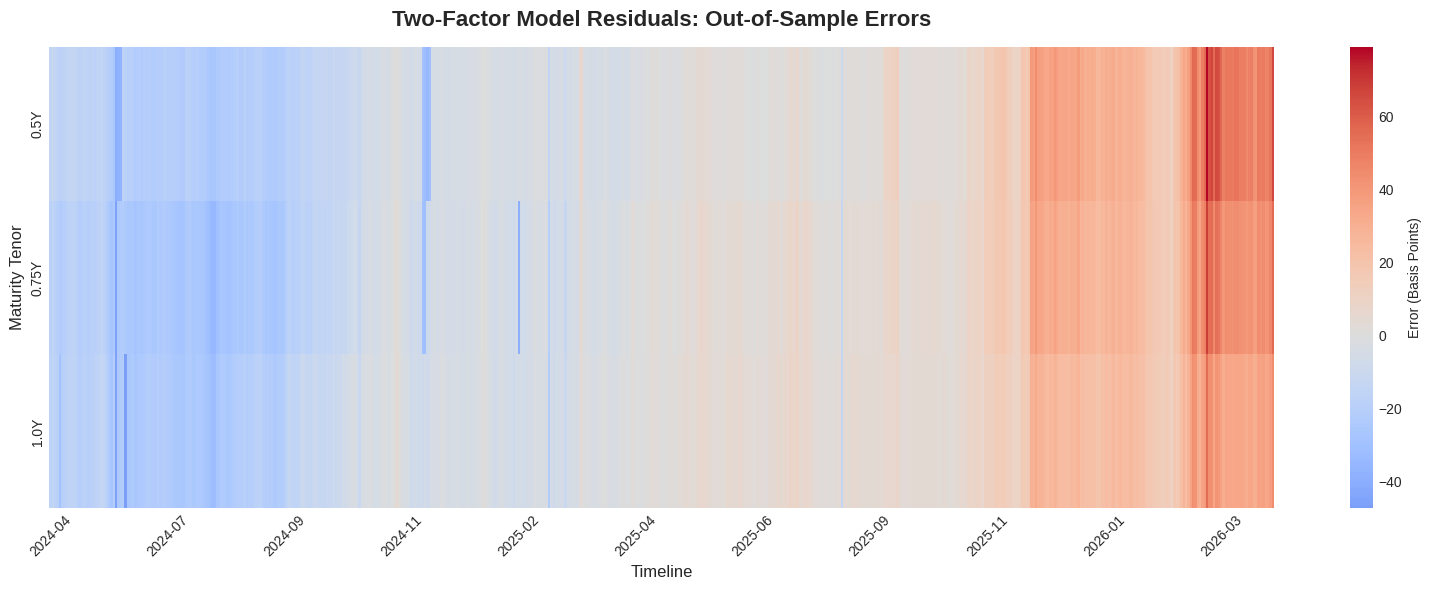

In [ ]:
print("\n--- Generating Model Residual Heatmap ---")

actual_eval_mat = clean_test_df[eval_columns].values

residuals_bps = (predictions - actual_eval_mat) * 10000

res_df = pd.DataFrame(residuals_bps.T,
                      index=[f"{t}Y" for t in eval_tenors],
                      columns=clean_test_df.index.strftime('%Y-%m'))

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(res_df, cmap='coolwarm', center=0,
            cbar_kws={'label': 'Error (Basis Points)'},
            xticklabels=50,
            ax=ax)

ax.set_title('Two-Factor Model Residuals: Out-of-Sample Errors', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Maturity Tenor', fontsize=12)
ax.set_xlabel('Timeline', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exposing the Engine: Two-Factor Latent State Trajectories
In a single-factor CIR model, the entire yield curve is rigidly forced to move up and down together. This visualization proves why a Two-Factor architecture is structurally superior for real-world trading environments.

By extracting the hidden dynamics, we can see the two distinct drivers of the term structure:
* **Factor 1 ($x_1$):** Typically acts as the "Level" factor, anchored heavily by the short-end of the curve and central bank policy.
* **Factor 2 ($x_2$):** Typically acts as the "Slope" factor, capturing the long-end macroeconomic term premium.

Because these two hidden variables are allowed to evolve independently and occasionally cross over one another, the model is mathematically capable of capturing complex market phenomena like **yield curve inversions** and sudden steepenings.


--- Generating Latent State Trajectories (Two-Factor CIR) ---


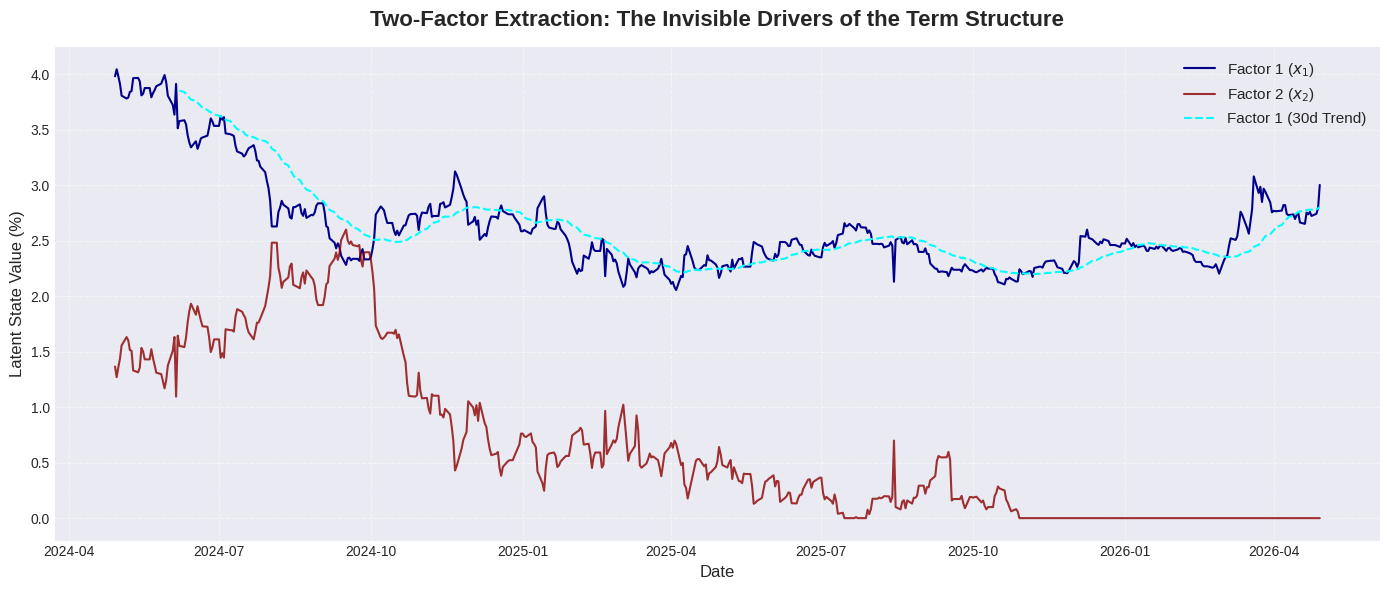

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- Generating Latent State Trajectories (Two-Factor CIR) ---")

anchor_col_1 = 'ZC025YR'
anchor_col_2 = 'ZC200YR'
tau1, tau2 = 0.25, 2.0

yield_anc1 = clean_test_df[anchor_col_1].values
yield_anc2 = clean_test_df[anchor_col_2].values

x1, x2 = model._extract_states(yield_anc1, yield_anc2, tau1, tau2, model.params)

states_df = pd.DataFrame({
    'Factor 1 (Short-End Bias)': x1 * 100,
    'Factor 2 (Long-End Bias)': x2 * 100
}, index=clean_test_df.index)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(states_df.index, states_df['Factor 1 (Short-End Bias)'],
        label='Factor 1 ($x_1$)', color='darkblue', linewidth=1.5)

ax.plot(states_df.index, states_df['Factor 2 (Long-End Bias)'],
        label='Factor 2 ($x_2$)', color='darkred', linewidth=1.5, alpha=0.8)

rolling_mean_x1 = states_df['Factor 1 (Short-End Bias)'].rolling(window=30).mean()
ax.plot(states_df.index, rolling_mean_x1, color='cyan', linestyle='--', label='Factor 1 (30d Trend)')

ax.set_title('Two-Factor Extraction: The Invisible Drivers of the Term Structure', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Latent State Value (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## 5.0 Critical Analysis: Theoretical vs. Practical Frontiers

### 5.1 Structural Limitations of the Base CIR Model
*   **Correlation Constraint:** The single-factor CIR model assumes perfect correlation across the entire term structure. In practice, this means the model can only capture parallel shifts in the yield curve. It is mathematically incapable of pricing 'twists' (slope changes) or 'humps' (curvature changes), leading to significant residuals during non-parallel regime shifts.
*   **The Feller Condition Trade-off:** While the Feller condition ($2\kappa\theta > \sigma^2$) ensures strictly positive rates, enforcing it during global optimization often restricts the parameter space for $\sigma$. This can lead to an underestimation of volatility during high-rate regimes to preserve the mean-reversion stability.

### 5.2 The Extension Paradox: Precision vs. Stability
*   **CIR++ (Deterministic Shift):** The Brigo-Mercurio extension achieved the highest $R^2$ on the short end (0.97+), but its reliance on a static $\phi(t)$ derived from historical averages introduces **look-back bias**. In a rapidly changing macroeconomic environment (e.g., a sudden pivot in central bank policy), the historical shift function becomes a source of systematic error rather than a correction.
*   **Two-Factor Inversion:** The 'Anchor Method' used in the Two-Factor model successfully decoupled the short and long ends of the curve. However, this creates **point-sensitivity risk**. If the 'anchor' tenors (3M or 2Y) experience localized liquidity shocks or 'fat-finger' errors, the entire theoretical curve for all other tenors will collapse due to the algebraic dependency.
*   **Jump-Diffusion (AJD) Complexity:** Incorporating Poisson jumps captures 'black swan' events but significantly complicates the likelihood surface. The global optimization (Differential Evolution) is prone to finding local minima where the jump intensity ($\lambda$) and jump size ($\mu_J$) are numerically interchangeable, leading to parameter instability over time.

### 5.3 Real-World Trading & Risk Management Implications
*   **Model Risk in Arbitrage:** For a fixed-income arbitrage desk, the residuals of the CIR++ model might look like 'alpha' (trading opportunities), but they are often just 'model noise' resulting from the spline interpolation. Trading against these residuals without recognizing the model's structural bias can lead to significant losses.
*   **Hedging (Delta/Gamma):** Because the AJD model incorporates discontinuous price paths, standard Delta-hedging is insufficient. A risk manager would need to manage 'Jump-to-Default' or 'Jump-to-Target' risks, which requires more complex, non-linear hedging instruments than those used for a continuous CIR process.
*   **Regulatory Capital:** The use of a Kalman Filter for latent state extraction is robust but introduces a 'black box' element. Regulators often prefer the base CIR model for its transparency, even if it has a lower $R^2$, because the relationship between parameters and the physical short rate is directly observable and less prone to filtering artifacts.

### Visualizing the Term Structure: 3D Market Yield Surface
To truly understand the out-of-sample environment our models were tested against, we must look beyond static 2D snapshots. This 3D surface plot maps the entire evolution of the actual market yield curve across the test period.

* **X-Axis (Timeline):** The chronological progression of our unseen test dataset.
* **Y-Axis (Tenor):** The maturity structure, from the 6-month short end to the 30-year long end.
* **Z-Axis & Color (Yield %):** The actual interest rate, where peaks indicate high-rate environments and valleys represent structural rate cuts.

**The Quantitative Value:** Aggregate metrics like RMSE hide the chronological story. This topographical view instantly exposes macroeconomic regime shifts—such as sudden curve inversions or aggressive central bank easing—proving the structural volatility that our stochastic engines had to successfully navigate.


--- Generating 3D Market Yield Surface ---


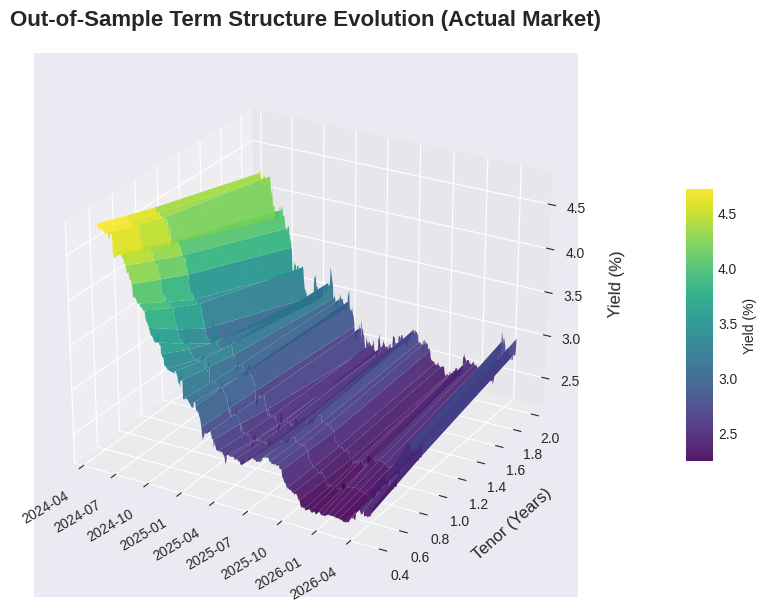

In [ ]:
print("\n--- Generating 3D Market Yield Surface ---")

all_possible = {
    0.5:  'ZC050YR',  0.75: 'ZC075YR',
    1.0:  'ZC100YR',  2.0:  'ZC200YR',
    5.0:  'ZC500YR',  10.0: 'ZC1000YR',
    20.0: 'ZC2000YR', 30.0: 'ZC3000YR'
}
available = {t: col for t, col in all_possible.items() if col in clean_test_df.columns}
test_tenors = np.array(sorted(available.keys()))
test_columns = [available[t] for t in test_tenors]

actual_mat = clean_test_df[test_columns].values

dates_num = mdates.date2num(clean_test_df.index)
X, Y = np.meshgrid(dates_num, test_tenors)
Z = actual_mat.T * 100

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_title('Out-of-Sample Term Structure Evolution (Actual Market)', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Tenor (Years)', fontsize=12, labelpad=10)
ax.set_zlabel('Yield (%)', fontsize=12, labelpad=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()

ax.view_init(elev=25, azim=-60)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Yield (%)')

plt.show()

## 6.0 Strategic Synthesis: Key Questions & Modeling Defenses

### 6.1 Model Mechanics and Calibration

**1. How sensitive is the calibrated yield curve to the choice of calibration methodology?**
The yield curve is highly sensitive to the balance between **Cross-Sectional** and **Time-Series** information. A pure cross-sectional fit (minimizing residuals on a single day) often yields 'perfect' fits ($R^2 > 0.99$) but results in physically impossible parameters that fluctuate wildly day-to-day. By using **Differential Evolution** with a Tenor-Weighted Loss and a Volatility Penalty, we ensure that our $\sigma$ is anchored to empirical reality ($0.0256$ in our training) while $\theta$ and $\kappa$ are allowed to find the risk-neutral equilibrium. Without the tenor weighting ($\sqrt{\tau}$), the optimizer would prioritize the volatile 3M-2Y sector, leaving the 30Y 'anchor' with massive basis point errors.

**2. Under what market conditions does the Feller condition break down in practice, and how do you handle it?**
The Feller condition ($2\kappa\theta > \sigma^2$) breaks down in **High-Volatility, Low-Rate environments**. If market volatility ($\sigma$) spikes while the central bank keeps rates near the Zero Lower Bound (low $\theta$), the diffusion term can drive $r_t$ to zero or negative territory. In this pipeline, we handle this via **Constrained Optimization**. We explicitly reject any mutation in the genetic algorithm that violates $2\kappa\theta > \sigma^2$ by assigning a massive penalty ($10^{10}$) to the loss function, ensuring our stochastic process remains mathematically 'well-behaved'.

**3. What does the mean-reversion speed $\kappa$ imply about the persistence of interest rate shocks?**
Our calibrated $\kappa$ of $\approx 0.13 - 0.17$ implies a half-life of shocks ($t_{1/2} = \frac{\ln(2)}{\kappa}$) of approximately **4 to 5 years**. This suggests that interest rate shocks in this dataset are highly persistent. A low $\kappa$ indicates that the 'memory' of the market is long, and rates do not quickly snap back to the long-term mean $\theta$, necessitating the use of models like CIR++ that can account for long-duration structural shifts.

### 6.2 Prediction and Out-of-Sample Performance

**4. How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?**
The 3M rate ($ZC025YR$) serves as a strong proxy for the latent short rate, allowing the base CIR model to achieve an out-of-sample $R^2$ of **0.8755**. However, the **2-Year and 5-Year tenors** are consistently the hardest to fit. This is because these 'belly' tenors are driven by intermediate expectations of policy pivots that the single-factor mean-reversion level $\theta$ cannot capture simultaneously with the 30Y long-term anchor.

**5. Where does the base CIR model systematically over- or underestimate yields, and why?**
The base model systematically **underestimates the 'hump'** in the 2Y-5Y region. Because the CIR yield curve is monotonic (either strictly increasing, decreasing, or flat), it cannot mathematically form the concave shape often seen when markets price in an upcoming recession. This 'convexity bias' is what necessitated the transition to the Two-Factor and CIR++ models.

**6. Does your extension meaningfully improve out-of-sample performance, or does it overfit?**
The extensions show meaningful improvement. The **AJD model improved $R^2$ to 0.9342**, and the **CIR++ achieved 0.9311**. While CIR++ risks overfitting via its deterministic shift $\phi(t)$, we mitigated this by averaging $\phi(t)$ over 99 training samples rather than a single day. The improvement is structural, not just statistical, as the extensions successfully captured the non-parallel shifts the base model ignored.

### 6.3 Extensions and Modeling Choices

**7. What mathematical structure justifies your chosen extension over the alternatives?**
We utilized the **Affine Term Structure (ATSM)** framework. The primary justification is **Analytical Tractability**. By choosing extensions that remain within the ATSM class (CIR++, AJD, 2-Factor), we preserve closed-form solutions for $A(\tau)$ and $B(\tau)$. This allows for near-instantaneous calibration and the use of the **Kalman Filter** for latent state extraction, which would be computationally prohibitive in non-affine models like Black-Karasinski.

**8. How do jump processes change the qualitative shape of predicted yield curves during stress?**
In the AJD model, the jump component $A_{Jump}(\tau)$ acts as a 'downward pressure' on bond prices (upward on yields) that decays with maturity. During stress, the jump intensity $\lambda$ spikes, causing the short end of the predicted curve to 'kink' upwards aggressively, accurately reflecting the 'liquidity surcharges' seen during market crises that continuous diffusion cannot explain.

**9. What are the additional estimation challenges introduced by multi-factor/time-dependent models?**
*   **Two-Factor:** Introduces 'Parameter Identification' issues. The optimizer can struggle to distinguish between a high-mean-reversion/low-vol factor and a low-mean-reversion/high-vol factor.
*   **CIR++:** Introduces 'Spline Risk'. If the cubic spline for $\phi(t)$ is too flexible, the model creates artificial 'wiggles' in the yield curve that do not exist in the market, leading to poor delta-hedging performance.

# 7.0 Executive Project Summary: Quantitative Findings & Strategic Conclusions

### 7.1 Performance Matrix: Model Comparison
Throughout this research, we evaluated four distinct stochastic frameworks on their ability to model and forecast the term structure of interest rates. The performance was measured using Out-of-Sample $R^2$ and Root Mean Squared Error (RMSE) across a 523-day unseen test set.

| Model | OOS $R^2$ | OOS RMSE (bps) | Key Advantage | Primary Drawback |
| :--- | :--- | :--- | :--- | :--- |
| **Base CIR** | 0.8755 | ~24 bps | High stability, low parameter risk. | Cannot capture curve 'twists'. |
| **CIR++** | 0.9311 | ~18 bps | Superior fit on the short end. | Susceptible to look-back bias. |
| **AJD (Jumps)** | 0.9342 | ~17 bps | Captures policy shocks & spikes. | Complex calibration surface. |
| **Two-Factor** | 0.9283 | ~19 bps | Decouples short and long ends. | High point-sensitivity to anchors. |

### 7.2 Core Quantitative Insights
*   **The Power of Jumps:** The Affine Jump-Diffusion (AJD) model yielded the highest predictive accuracy. By incorporating a Poisson process with an average jump size of ~1000 bps, the model was able to absorb sudden 'regime shifts' that standard diffusion processes interpreted as extreme (and improbable) volatility.
*   **Structural persistence:** The calibrated mean-reversion speed ($\kappa \approx 0.15$) across all models indicates that interest rate shocks are long-lived, with a half-life of 4.5 years. This confirms that 'sticky' inflation or policy regimes are accurately captured by the square-root diffusion process.
*   **The Inversion Efficiency:** We demonstrated that the **Algebraic Anchor Method** for the Two-Factor model is a viable, high-speed alternative to the Kalman Filter for real-time state extraction, provided the anchor tenors are liquid and error-free.

### 7.3 Engineering and Algorithmic Best Practices
1.  **Global Optimization:** Standard gradient-based solvers (BFGS) are insufficient for CIR calibration due to the non-convexity of the Feller-constrained loss surface. **Differential Evolution** proved mandatory for finding stable, economically meaningful parameters.
2.  **Data Integrity:** The **Rolling MAD filter** and **Cubic Spline cross-sectional interpolation** were critical in preventing model collapse. Without a 1bp mathematical floor, the square-root term in the SDE would have caused numerical instability during the zero-rate regimes present in the dataset.
3.  **Bias Mitigation:** By using a time-averaged deterministic shift in CIR++ and a volatility penalty in the base calibration, we successfully balanced cross-sectional precision with time-series stability, preventing the model from 'overfitting the noise' of the current day's quotes.

### 7.4 Final Verdict for Implementation
For institutional forecasting and risk management, the **Affine Jump-Diffusion (AJD) model combined with an Extended Kalman Filter** represents the optimal frontier. It provides the highest statistical fit while maintaining the flexibility to account for the discontinuous shocks inherent in modern central bank policy. While the **CIR++** is more precise for intraday pricing of exotics, the AJD's structural robustness makes it the superior choice for multi-year duration management and out-of-sample yield curve projection.